In [23]:
import pandas as pd
import numpy as np
from pathlib import Path
import sys
from tqdm import tqdm
from scipy.optimize import linear_sum_assignment
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
from scipy.spatial.distance import pdist, squareform
from sklearn.decomposition import PCA
import json
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 300

# ── Configuration ─────────────────────────────────────────────────────────────
# Set to 3 for 3-fold boosting (3× data) or 5 for 5-fold boosting (5× data).
N_FOLDS = 5

# ── Paths ─────────────────────────────────────────────────────────────────────
BUNDLE_DIR = Path.cwd().resolve()
ROOT_DIR   = BUNDLE_DIR.parents[0]
DATA_DIR   = ROOT_DIR / 'data'

STEPPED_AVG_DIR  = DATA_DIR / 'protein' / 'stepped_avg' / f'{N_FOLDS}fold_adj'
CELL_LINEAGE_PATH = DATA_DIR / 'cell_lineage.json'
CELL_TYPE_PATH    = DATA_DIR / '2023-06-29_entropy_cell_key_V2.csv'
PROTEIN_DATA_DIR  = DATA_DIR / 'protein' / 'aggregated_all'
TISSUE_SPECIFIC_TF_PATH = PROTEIN_DATA_DIR / 'tissue_specific_tf.tsv'

RESULTS_DIR = BUNDLE_DIR / 'results' / f'stepped_avg_{N_FOLDS}fold'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

ZSCORE_PATH              = RESULTS_DIR / f's3_stepped_{N_FOLDS}fold_zscore.csv'
PHASE2_CV_SUMMARY_PATH   = RESULTS_DIR / 'phase2_cv_summary.csv'
FEATURE_EMBEDDINGS_PATH  = RESULTS_DIR / 'embeddings_32d.csv'
SELECTED_PROTEINS_PATH   = RESULTS_DIR / 'nn_selected_proteins.tsv'

if str(ROOT_DIR) not in sys.path:
    sys.path.insert(0, str(ROOT_DIR))
if str(BUNDLE_DIR) not in sys.path:
    sys.path.insert(0, str(BUNDLE_DIR))

def map_names(did):
    if   did == 'P4a': return 'Z3'
    elif did == 'P4p': return 'Z2'
    elif did == 'P0a': return 'AB'
    else: return did

print(f'N_FOLDS         : {N_FOLDS}')
print(f'Stepped-avg dir : {STEPPED_AVG_DIR}')
print(f'Results dir     : {RESULTS_DIR}')

N_FOLDS         : 5
Stepped-avg dir : /Users/bingran/code/embryogenesis/data/protein/stepped_avg/5fold_adj
Results dir     : /Users/bingran/code/embryogenesis/expression_embedding/results/stepped_avg_5fold


In [24]:
# ── Lineage tree traversal (identical to protein_feature_select) ───────────────
with CELL_LINEAGE_PATH.open('r', encoding='utf-8') as f:
    lineage_data = json.load(f)

terminal_nodes    = []
intermediate_nodes = []
descendant_list_dict = defaultdict(list)

def dfs(node, parent, ancestors=[]):
    children    = node.get('children', [])
    lookup_name = map_names(node['did'])
    if len(children) == 0:
        terminal_nodes.append(lookup_name)
        for ancestor in ancestors:
            descendant_list_dict[ancestor].append(lookup_name)
    else:
        intermediate_nodes.append(lookup_name)
        for child in children:
            dfs(child, node, ancestors + [lookup_name])

dfs(lineage_data, None)
print(f'Internal nodes: {len(intermediate_nodes)}  |  Terminal nodes: {len(terminal_nodes)}')

Internal nodes: 1091  |  Terminal nodes: 1092


In [25]:
# ── Cell type assignment (identical to protein_feature_select) ─────────────────
cell_type_df  = pd.read_csv(CELL_TYPE_PATH)
cell_type_dict = {}

for node in terminal_nodes:
    cur = cell_type_df[cell_type_df['wormweb.lineage'] == node]
    if len(cur) == 0:
        print(f'Warning: no cell type for {node}')
        continue
    types = cur['wormweb.type']
    types = types[~types.isna()].unique()
    if len(types) == 0:
        cell_type_dict[node] = 'programmed_death'
        continue
    if len(types) > 1:
        print(f'Warning: multiple types for {node}: {types}')
    cell_type_dict[node] = types[0]

# Ordered list: most-frequent types first, programmed_death last
cell_types = list(set(cell_type_dict.values()))
cell_types  = [ct for ct in cell_types if ct != 'programmed_death']
cell_types  = sorted(cell_types, key=lambda x: sum(1 for v in cell_type_dict.values() if v == x), reverse=True)
cell_types.append('programmed_death')
cell_type_to_int = {ct: i for i, ct in enumerate(cell_types)}

cell_type_one_hot = {}
for node, ct in cell_type_dict.items():
    oh = np.zeros(len(cell_types))
    oh[cell_type_to_int[ct]] = 1
    cell_type_one_hot[node] = oh

# Soft labels for intermediate nodes: normalised descendant type distribution
for node in intermediate_nodes:
    desc_types = [cell_type_one_hot[d] for d in descendant_list_dict[node]]
    if len(desc_types) == 0:
        print(f'Warning: no descendants for {node}')
        cell_type_one_hot[node] = np.zeros(len(cell_types))
        continue
    s = np.sum(desc_types, axis=0)
    cell_type_one_hot[node] = s / s.sum()

print(f'Cell types ({len(cell_types)}): {cell_types}')

Cell types (18): ['neuron', 'hypoderm', 'muscle', 'repro', 'intestine', 'epithelium', 'socket', 'sheath', 'other', 'marginal', 'valve', 'coelomocyte', 'excretory', 'gland', 'rectal', 'tail', 'mesoderm', 'programmed_death']


In [26]:
# ── Load stepped-avg folds and stack ──────────────────────────────────────────
#
# Each fold_k.csv has shape (N_CELLS, N_PROTEINS): rows = cells, cols = proteins.
# We concatenate them vertically to create a boosted dataset of
# N_FOLDS × N_CELLS rows.  A `groups` array (cell index repeated N_FOLDS times)
# is constructed so that all replicas of the same cell land in the same CV fold,
# preventing any train/val leakage.

fold_dfs = []
for k in range(N_FOLDS):
    fold_path = STEPPED_AVG_DIR / f'fold_{k}.csv'
    df = pd.read_csv(fold_path, index_col=0)
    fold_dfs.append(df)
    print(f'  fold_{k}: {df.shape}  (cells × proteins)')

# Verify all folds share the same index and columns
assert all((fd.index == fold_dfs[0].index).all() for fd in fold_dfs), 'Cell names mismatch across folds'
assert all((fd.columns == fold_dfs[0].columns).all() for fd in fold_dfs), 'Protein names mismatch across folds'

# cell order from the fold files (used to align y, weights, groups)
cell_order   = fold_dfs[0].index.tolist()   # e.g. ['ABa', 'ABal', ...]
protein_order = fold_dfs[0].columns.tolist() # e.g. ['AHA-1_SYS135', ...]
N_CELLS    = len(cell_order)
N_PROTEINS = len(protein_order)

# Stacked matrix: shape (N_FOLDS * N_CELLS, N_PROTEINS)
stacked_cells = pd.concat(fold_dfs, axis=0)
stacked_cells = stacked_cells.fillna(0)

# Groups: cell index (0..N_CELLS-1) repeated N_FOLDS times so all replicas
# of a cell stay in the same CV split.
cell_index = np.arange(N_CELLS)
groups     = np.tile(cell_index, N_FOLDS)   # shape (N_FOLDS * N_CELLS,)

print(f'\nStacked shape : {stacked_cells.shape}  ({N_FOLDS} × {N_CELLS} = {N_FOLDS * N_CELLS} samples)')
print(f'groups range  : {groups.min()} .. {groups.max()}  (unique cells = {np.unique(groups).size})')

  fold_0: (1204, 291)  (cells × proteins)
  fold_1: (1204, 291)  (cells × proteins)
  fold_2: (1204, 291)  (cells × proteins)
  fold_3: (1204, 291)  (cells × proteins)
  fold_4: (1204, 291)  (cells × proteins)

Stacked shape : (6020, 291)  (5 × 1204 = 6020 samples)
groups range  : 0 .. 1203  (unique cells = 1204)


In [27]:
stacked_cells.head()

,AHA-1_SYS135,AHR-1_SYS571,ALR-1_RW10757,ALR-1_SYS139,ALY-1_SYS619,ALY-2_SYS721,APTF-1_SYS114,ARID-1_SYS679,AST-1_SYS1190,ATF-7_SYS495,...,Y73E7A.1_SYS714,Y75B8A.6_SYS80,ZAG-1_SYS102,ZFH-2_SYS986,ZIP-3_SYS669,ZIP-8_SYS163,ZIP-8_SYS454,ZTF-11_SYS99,ZTF-30_SYS164,ZTF-6_SYS464
Cell-name,,,,,,,,,,,,,,,,,,,,,
ABa,0.000000,0.0,0.0,0.0000,0.000000,7.548333,0.100000,0.000000,0.000000,0.0,...,9.998333,0.625000,0.06,0.0,0.0,0.000000,0.000000,0.175000,0.048333,0.000000
ABal,0.072222,0.0,0.0,0.0000,0.000000,14.404444,0.000000,0.197778,0.000000,0.0,...,0.913333,0.000000,0.00,0.0,0.0,0.000000,0.106667,0.000000,0.000000,0.000000
ABala,0.000000,0.0,0.0,0.0000,2.003333,17.315556,0.000000,7.767778,0.000000,0.0,...,3.638889,0.000000,0.00,0.0,0.0,0.000000,0.000000,0.000000,0.573333,0.000000
ABalaa,0.000000,0.0,0.0,0.0000,26.153636,28.928182,0.789091,9.317273,0.059091,0.0,...,2.989091,0.071818,0.00,0.0,0.0,0.000000,0.240909,0.169091,0.000000,0.000000
ABalaaa,0.089167,0.0,0.0,0.1125,100.647500,44.266667,0.000000,14.754167,0.000000,0.0,...,3.361667,0.003333,0.00,0.0,0.0,0.023333,0.016667,1.087500,0.001667,0.015833


In [28]:
# ── Z-score normalisation ─────────────────────────────────────────────────────
# Transpose to proteins × (N_FOLDS * N_CELLS), then z-score each protein row
# across all boosted samples.  Drop any protein that is all-zero (not observed).

protein_exp_stacked = stacked_cells.T   # proteins × boosted_cells
protein_exp_stacked = protein_exp_stacked[~(protein_exp_stacked == 0).all(axis=1)]
protein_exp_zscore  = protein_exp_stacked.apply(lambda x: (x - x.mean()) / x.std(), axis=1)

print(f'After dropping all-zero proteins: {protein_exp_zscore.shape}  (proteins × boosted_samples)')
protein_exp_zscore.head()

After dropping all-zero proteins: (291, 6020)  (proteins × boosted_samples)


Cell-name,ABa,ABal,ABala,ABalaa,ABalaaa,ABalaaaa,ABalaaaal,ABalaaaala,ABalaaaalal,ABalaaaalar,...,MSppppaa,MSppppap,MSppppp,MSpppppa,MSpppppp,P2,P3,P4,Z2,Z3
AHA-1_SYS135,-0.707852,-0.629573,-0.707852,-0.707852,-0.611208,-0.522873,-0.386520,-0.247387,0.427941,-0.251646,...,0.127735,-0.015876,-0.650295,0.314122,-0.297384,-0.545273,-0.707852,-0.621659,-0.538047,-0.338455
AHR-1_SYS571,-0.709360,-0.709360,-0.709360,-0.709360,-0.709360,-0.709360,-0.622724,-0.365672,0.090367,1.303281,...,-0.468462,0.294379,-0.661275,-0.411665,-0.175127,-0.709360,-0.709360,-0.709360,-0.677044,-0.700087
ALR-1_RW10757,-0.398034,-0.398034,-0.398034,-0.398034,-0.398034,-0.383223,-0.337989,-0.105171,-0.341116,0.290023,...,-0.316411,-0.398034,-0.395653,-0.337892,-0.398034,-0.398034,-0.398034,-0.365724,-0.312845,-0.170232
ALR-1_SYS139,-0.345979,-0.345979,-0.345979,-0.345979,-0.317306,-0.106402,-0.258274,-0.305118,-0.255076,-0.339723,...,-0.197836,-0.256615,-0.286304,0.023663,-0.273382,-0.345979,-0.306590,-0.329352,-0.343218,-0.343534
ALY-1_SYS619,-1.811187,-1.811187,-1.737710,-0.851938,1.880308,1.571845,1.661285,0.605042,-0.495215,0.696635,...,0.163757,0.466335,-0.291260,-0.404902,-0.465372,-1.811187,-1.811187,-1.809580,-1.811187,-1.792826


In [29]:
protein_exp_zscore.to_csv(ZSCORE_PATH)
print(f'Saved z-scored matrix -> {ZSCORE_PATH}')

Saved z-scored matrix -> /Users/bingran/code/embryogenesis/expression_embedding/results/stepped_avg_5fold/s3_stepped_5fold_zscore.csv


In [30]:
# ── Build X, y, terminal_mask ──────────────────────────────────────────────────
#
# X: (N_FOLDS * N_CELLS, N_PROTEINS_KEPT) – one row per boosted sample
# y: soft label for each sample (same label for all K replicas of a cell)
# terminal_mask: True for samples whose underlying cell is a terminal node
#
# The cell name for boosted sample i is cell_order[i % N_CELLS] since
# fold_0 occupies rows 0..N_CELLS-1, fold_1 occupies rows N_CELLS..2*N_CELLS-1, …

X = protein_exp_zscore.values.T   # (N_FOLDS * N_CELLS, N_PROTEINS_KEPT)

# cell name for each boosted row
boosted_cell_names = np.array(cell_order * N_FOLDS)  # repeats the list N_FOLDS times

y             = np.array([cell_type_one_hot[map_names(c)] for c in boosted_cell_names])
terminal_mask = np.array([len(descendant_list_dict[map_names(c)]) == 0 for c in boosted_cell_names])

print(f'X shape           : {X.shape}')
print(f'y shape           : {y.shape}')
print(f'terminal samples  : {terminal_mask.sum()} / {len(terminal_mask)}')
print(f'groups shape      : {groups.shape}')

X shape           : (6020, 291)
y shape           : (6020, 18)
terminal samples  : 2470 / 6020
groups shape      : (6020,)


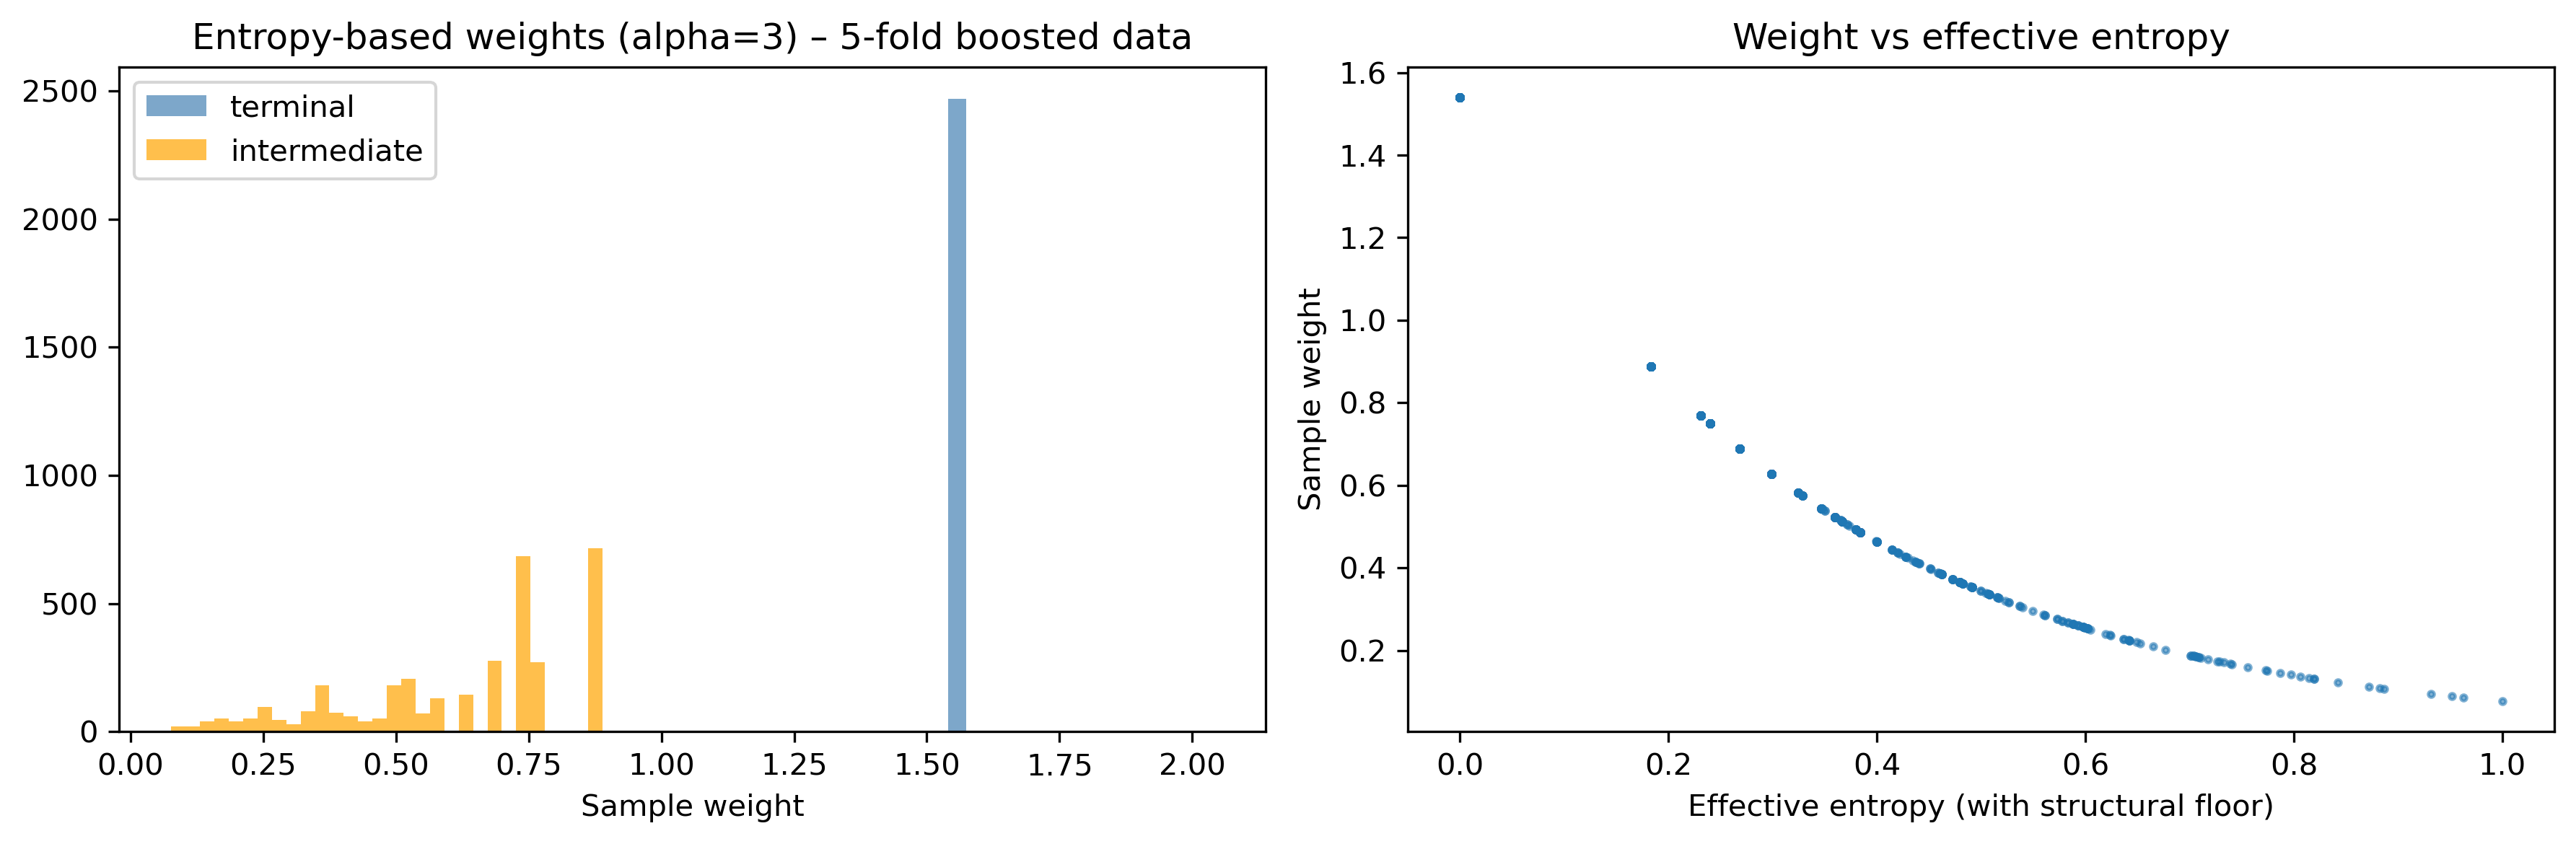

Hard nodes  – mean_w=1.540, max_w=1.540
Soft nodes  – mean_w=0.624, max_w=0.889


In [31]:
# ── Entropy-based sample weights (identical logic to protein_feature_select) ───

def entropy_based_weights(y_soft, n_descendants, alpha=3.0):
    y_clipped  = np.clip(y_soft, 1e-10, 1.0)
    entropies  = -np.sum(y_clipped * np.log(y_clipped), axis=1)
    max_ent    = np.log(y_soft.shape[1])
    norm_ent   = entropies / max_ent
    max_desc   = max(n_descendants.max(), 1)
    struct_floor = np.log1p(n_descendants) / np.log1p(max_desc)
    eff_ent    = np.maximum(norm_ent, struct_floor)
    weights    = np.exp(-alpha * eff_ent)
    return (weights / weights.mean()).astype(np.float32)

n_descendants    = np.array([len(descendant_list_dict[map_names(c)]) for c in boosted_cell_names])
sample_weights_v2 = entropy_based_weights(y, n_descendants, alpha=3.0)

# ── Visualise weight distributions ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.hist(sample_weights_v2[terminal_mask],  bins=30, alpha=0.7, color='steelblue', label='terminal')
ax.hist(sample_weights_v2[~terminal_mask], bins=30, alpha=0.7, color='orange',    label='intermediate')
ax.set_title(f'Entropy-based weights (alpha=3) – {N_FOLDS}-fold boosted data')
ax.set_xlabel('Sample weight')
ax.legend()

max_desc_all   = max(n_descendants.max(), 1)
struct_fl_all  = np.log1p(n_descendants) / np.log1p(max_desc_all)
norm_ent_all   = -np.sum(np.clip(y, 1e-10, 1) * np.log(np.clip(y, 1e-10, 1)), axis=1) / np.log(y.shape[1])
eff_ent_all    = np.maximum(norm_ent_all, struct_fl_all)

ax = axes[1]
ax.scatter(eff_ent_all, sample_weights_v2, alpha=0.15, s=4)
ax.set_xlabel('Effective entropy (with structural floor)')
ax.set_ylabel('Sample weight')
ax.set_title('Weight vs effective entropy')

plt.tight_layout()
plt.show()

print(f'Hard nodes  – mean_w={sample_weights_v2[terminal_mask].mean():.3f}, max_w={sample_weights_v2[terminal_mask].max():.3f}')
print(f'Soft nodes  – mean_w={sample_weights_v2[~terminal_mask].mean():.3f}, max_w={sample_weights_v2[~terminal_mask].max():.3f}')

In [32]:
from feature_selection import (
    SparseGateClassifier,
    FocusedClassifier,
    soft_cross_entropy,
    train_epoch,
    eval_accuracy,
    eval_prediction_metrics,
    cross_validate_features,
    cross_validate_focused,
    train_one_pass,
    train_focused,
)

print('feature_selection module loaded.')

feature_selection module loaded.


Device: mps
[stepped-avg 5fold phase1] config 1/18 start {'l1_lambda': 0.002, 'hidden_dims': (128, 64), 'dropout': 0.2}
[stepped-avg 5fold phase1] config 1/18 fold 1/5 train_acc=1.0000 val_acc=0.6700 val_loss=1.7850 selector_epochs=300
[stepped-avg 5fold phase1] config 1/18 fold 2/5 train_acc=1.0000 val_acc=0.7153 val_loss=1.4395 selector_epochs=295
[stepped-avg 5fold phase1] config 1/18 fold 3/5 train_acc=1.0000 val_acc=0.7184 val_loss=1.5061 selector_epochs=296
[stepped-avg 5fold phase1] config 1/18 fold 4/5 train_acc=1.0000 val_acc=0.7712 val_loss=1.5240 selector_epochs=292
[stepped-avg 5fold phase1] config 1/18 fold 5/5 train_acc=1.0000 val_acc=0.7705 val_loss=1.1183 selector_epochs=290
[stepped-avg 5fold phase1] config 1/18 done mean_val_acc=0.7291 mean_train_acc=1.0000 mean_overfit_gap=0.2709 stability=0.6284 score=0.6617
[stepped-avg 5fold phase1] config 2/18 start {'l1_lambda': 0.002, 'hidden_dims': (128, 64), 'dropout': 0.3}
[stepped-avg 5fold phase1] config 2/18 fold 1/5 trai

,l1_lambda,hidden_dims,dropout,mean_val_acc,mean_train_acc,mean_overfit_gap,mean_jaccard,mean_topk_frequency,consensus_ratio,selection_stability_score,score
0,0.002,"(128, 64, 32)",0.3,0.7281,1.0,0.2719,0.5515,0.8267,0.6667,0.6942,0.6874
1,0.004,"(128, 64, 32)",0.3,0.7326,1.0,0.2674,0.5015,0.8000,0.7333,0.6599,0.6768
2,0.008,"(128, 64, 32)",0.3,0.7288,1.0,0.2712,0.5023,0.8000,0.6667,0.6598,0.6740
3,0.002,"(64, 32)",0.3,0.7282,1.0,0.2718,0.4762,0.7867,0.6000,0.6437,0.6672
4,0.008,"(64, 32)",0.3,0.7291,1.0,0.2709,0.4671,0.7867,0.6000,0.6374,0.6654
5,0.004,"(128, 64)",0.3,0.7278,1.0,0.2722,0.4663,0.7733,0.5333,0.6334,0.6628
6,0.002,"(128, 64)",0.2,0.7291,1.0,0.2709,0.4541,0.7733,0.6667,0.6284,0.6617
7,0.004,"(64, 32)",0.3,0.7273,1.0,0.2727,0.4396,0.7600,0.6000,0.6155,0.6553



Best selector config: {'l1_lambda': 0.002, 'hidden_dims': (128, 64, 32), 'dropout': 0.3}


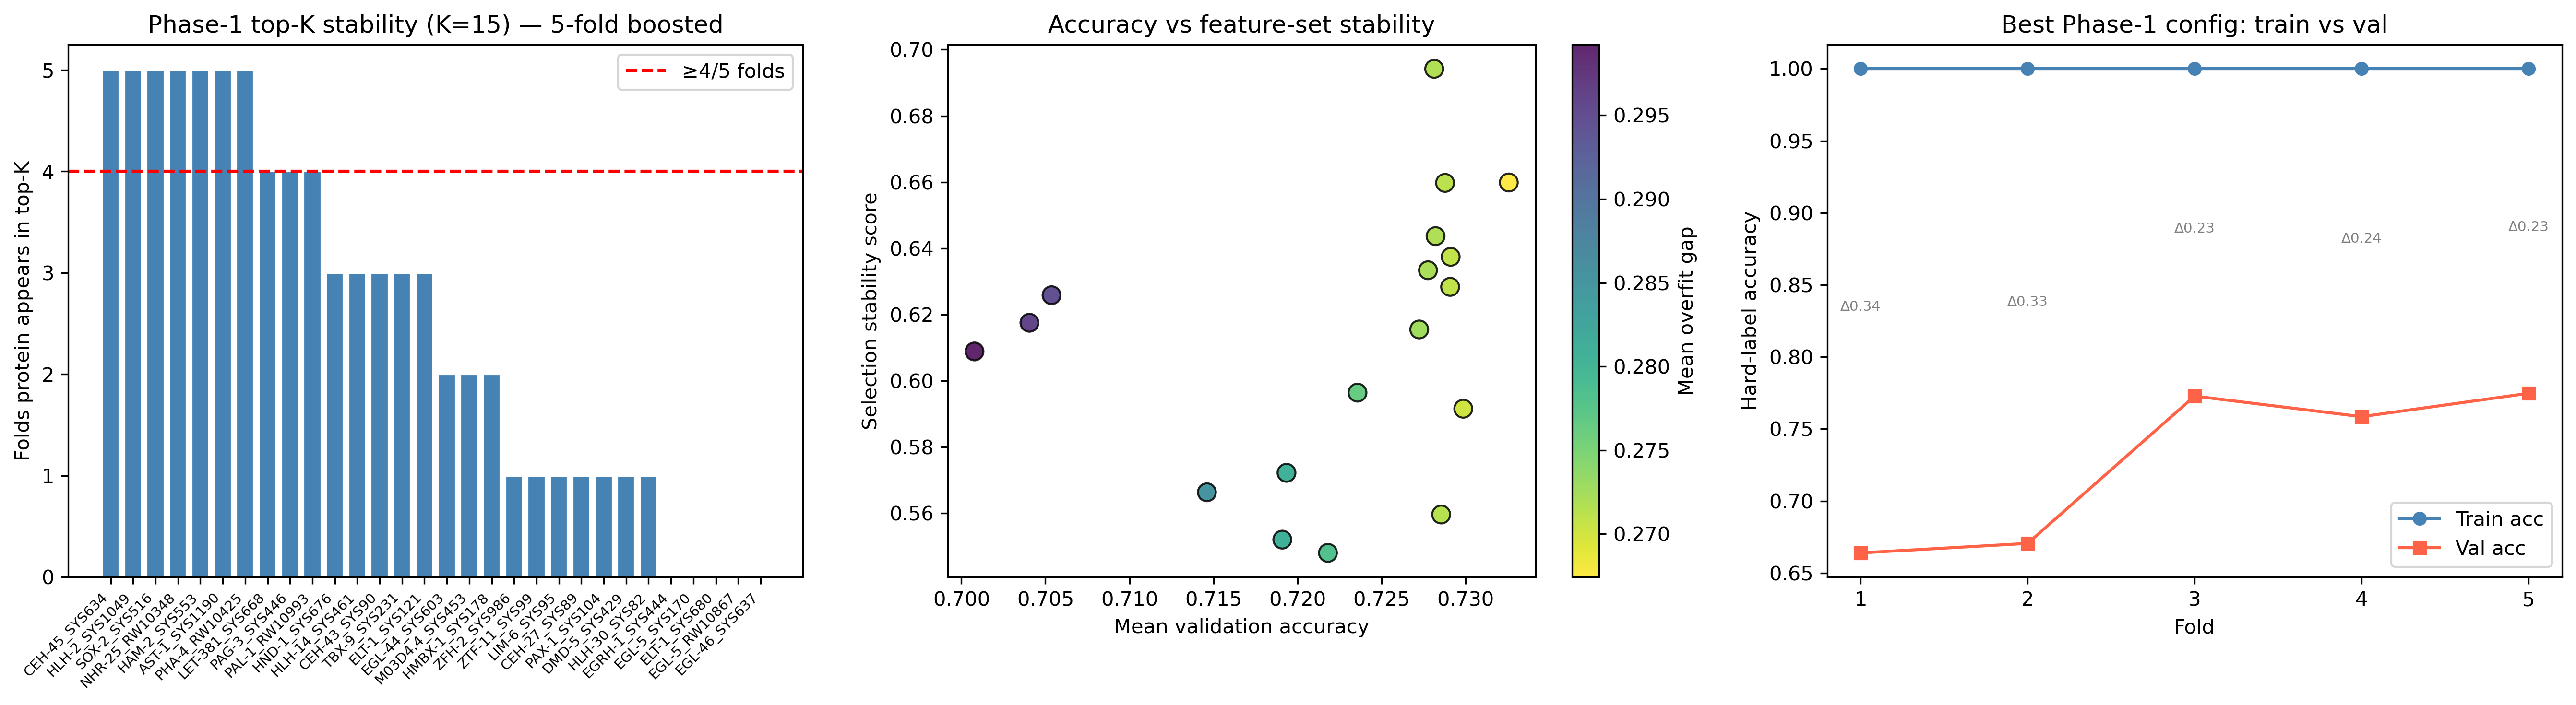

In [33]:
import torch
import torch.nn.functional as F

device = (torch.device('mps')  if torch.mps.is_available()  else
          torch.device('cuda') if torch.cuda.is_available() else
          torch.device('cpu'))
print(f'Device: {device}')

feature_names = np.array(protein_exp_zscore.index.tolist())

X_t    = torch.FloatTensor(X)
y_t    = torch.FloatTensor(y)
w_t    = torch.FloatTensor(sample_weights_v2)
term_t = torch.BoolTensor(terminal_mask)

PHASE1_STABILITY_K = 15

# ── Phase 1 CV ────────────────────────────────────────────────────────────────
# `groups` ensures all N_FOLDS replicas of a cell go to the same CV split,
# preventing identity leakage from the data-boosting step.

PHASE1_PARAM_GRID = {
    'l1_lambda':   [0.002, 0.004, 0.008],
    'hidden_dims': [(128, 64), (128, 64, 32), (64, 32)],
    'dropout':     [0.2, 0.3],
}

PHASE1_SCORE_WEIGHTS = {
    'val_acc':             0.60,
    'selection_stability': 0.40,
    'overfit_gap':         0.10,
}

PHASE1_STABILITY_WEIGHTS = {
    'jaccard':         0.50,
    'topk_frequency':  0.35,
    'spearman':        0.15,
}

PHASE1_CV_EPOCHS = 300
CV_VERBOSE       = True
PHASE1_CV_EARLY_STOPPING_PATIENCE  = 25
PHASE2_SELECTOR_EARLY_STOPPING_PATIENCE = 20
PHASE2_CV_EARLY_STOPPING_PATIENCE  = 25
FINAL_PHASE1_EARLY_STOPPING_PATIENCE = 30
FINAL_PHASE2_EARLY_STOPPING_PATIENCE = 30

cv_results, best_selector_config = cross_validate_features(
    X, y, sample_weights_v2, terminal_mask,
    param_grid               = PHASE1_PARAM_GRID,
    groups                   = groups,
    n_splits                 = 5,
    n_select                 = PHASE1_STABILITY_K,
    n_epochs                 = PHASE1_CV_EPOCHS,
    device                   = str(device),
    score_weights            = PHASE1_SCORE_WEIGHTS,
    stability_metric_weights = PHASE1_STABILITY_WEIGHTS,
    early_stopping_patience  = PHASE1_CV_EARLY_STOPPING_PATIENCE,
    verbose                  = CV_VERBOSE,
    log_prefix               = f'stepped-avg {N_FOLDS}fold phase1',
)

summary_rows = []
for r in cv_results:
    summary_rows.append({**r['config'], **r['summary'], 'score': round(r['score'], 5)})
summary_df = pd.DataFrame(summary_rows).sort_values('score', ascending=False)
best_result = cv_results[0]

display_cols = [
    'l1_lambda', 'hidden_dims', 'dropout',
    'mean_val_acc', 'mean_train_acc', 'mean_overfit_gap',
    'mean_jaccard', 'mean_topk_frequency', 'consensus_ratio',
    'selection_stability_score', 'score',
]
print('\nTop Phase-1 configs:')
display(summary_df[display_cols].head(8).round(4))
print(f'\nBest selector config: {best_selector_config}')

# ── Plot Phase-1 results ─────────────────────────────────────────────────────
freq         = best_result['stability']['feature_frequency']
top_freq_idx = np.argsort(freq)[::-1][:PHASE1_STABILITY_K * 2]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
ax.bar(range(len(top_freq_idx)), freq[top_freq_idx], color='steelblue', edgecolor='white')
ax.set_xticks(range(len(top_freq_idx)))
ax.set_xticklabels([feature_names[i] for i in top_freq_idx], rotation=45, ha='right', fontsize=7)
ax.set_ylabel('Folds protein appears in top-K')
ax.set_title(f'Phase-1 top-K stability (K={PHASE1_STABILITY_K}) — {N_FOLDS}-fold boosted')
ax.axhline(4, color='red', linestyle='--', label='≥4/5 folds')
ax.legend()

ax = axes[1]
ax.scatter(
    summary_df['mean_val_acc'],
    summary_df['selection_stability_score'],
    s=80, c=summary_df['mean_overfit_gap'], cmap='viridis_r',
    edgecolor='black', alpha=0.85,
)
ax.set_xlabel('Mean validation accuracy')
ax.set_ylabel('Selection stability score')
ax.set_title('Accuracy vs feature-set stability')
plt.colorbar(ax.collections[0], ax=ax, label='Mean overfit gap')

ax = axes[2]
fold_train = [fr['train_acc'] for fr in best_result['fold_results']]
fold_val   = [fr['val_acc']   for fr in best_result['fold_results']]
folds_x    = list(range(1, len(fold_train) + 1))
ax.plot(folds_x, fold_train, 'o-', label='Train acc', color='steelblue')
ax.plot(folds_x, fold_val,   's-', label='Val acc',   color='tomato')
for i, (tr, va) in enumerate(zip(fold_train, fold_val)):
    ax.annotate(f'Δ{tr - va:.2f}', xy=(i + 1, (tr + va) / 2), ha='center', fontsize=7, color='gray')
ax.set_xlabel('Fold')
ax.set_ylabel('Hard-label accuracy')
ax.set_title('Best Phase-1 config: train vs val')
ax.set_xticks(folds_x)
ax.legend()

plt.tight_layout()
plt.show()

[stepped-avg 5fold phase2 selector] fold 1/5 start train=4815 val=1205
[stepped-avg 5fold phase2 selector] fold 1/5 ready selector_epochs=250 top_gate=0.3694
[stepped-avg 5fold phase2 selector] fold 2/5 start train=4815 val=1205
[stepped-avg 5fold phase2 selector] fold 2/5 ready selector_epochs=250 top_gate=0.3432
[stepped-avg 5fold phase2 selector] fold 3/5 start train=4815 val=1205
[stepped-avg 5fold phase2 selector] fold 3/5 ready selector_epochs=250 top_gate=0.3518
[stepped-avg 5fold phase2 selector] fold 4/5 start train=4815 val=1205
[stepped-avg 5fold phase2 selector] fold 4/5 ready selector_epochs=236 top_gate=0.3573
[stepped-avg 5fold phase2 selector] fold 5/5 start train=4820 val=1200
[stepped-avg 5fold phase2 selector] fold 5/5 ready selector_epochs=221 top_gate=0.3434
[stepped-avg 5fold phase2] config 1/48 start {'n_select': 10, 'hidden_dims': (32,), 'dropout': 0.1, 'dist_lambda': 0.0}
[stepped-avg 5fold phase2] config 1/48 fold 1/5 train_acc=0.8584 val_acc=0.6120 expected_t

,n_select,hidden_dims,dropout,dist_lambda,mean_val_acc,mean_expected_target_probability,mean_soft_cross_entropy,mean_overfit_gap,mean_jaccard,consensus_ratio,n_parameters,normalized_param_count,score
0,25,"(32,)",0.1,0.0,0.6958,0.6033,1.2865,0.2922,0.5216,0.6800,1490,0.0396,0.5426
1,25,"(32,)",0.2,0.1,0.6861,0.5933,1.1956,0.2849,0.5216,0.6800,1490,0.0396,0.5359
2,25,"(32,)",0.1,0.1,0.6854,0.5994,1.2676,0.3045,0.5216,0.6800,1490,0.0396,0.5341
3,20,"(32,)",0.2,0.1,0.6846,0.5801,1.2594,0.2559,0.4884,0.6000,1330,0.0264,0.5328
4,15,"(64, 32)",0.2,0.0,0.7055,0.5787,1.1879,0.2685,0.5332,0.7333,3890,0.2375,0.5280
5,25,"(64, 32)",0.2,0.1,0.7021,0.6182,1.2398,0.2958,0.5216,0.6800,4530,0.2902,0.5242
6,25,"(32,)",0.2,0.0,0.6686,0.5922,1.2264,0.3064,0.5216,0.6800,1490,0.0396,0.5228
7,15,"(32,)",0.2,0.1,0.6597,0.5448,1.2990,0.2390,0.5332,0.7333,1170,0.0132,0.5212
8,10,"(32,)",0.1,0.0,0.6627,0.4987,1.3396,0.1655,0.5073,0.7000,1010,0.0000,0.5208
9,15,"(64, 32)",0.2,0.1,0.6945,0.5769,1.2477,0.2778,0.5332,0.7333,3890,0.2375,0.5201



Best Phase-2 config: {'n_select': 25, 'hidden_dims': (32,), 'dropout': 0.1, 'dist_lambda': 0.0}


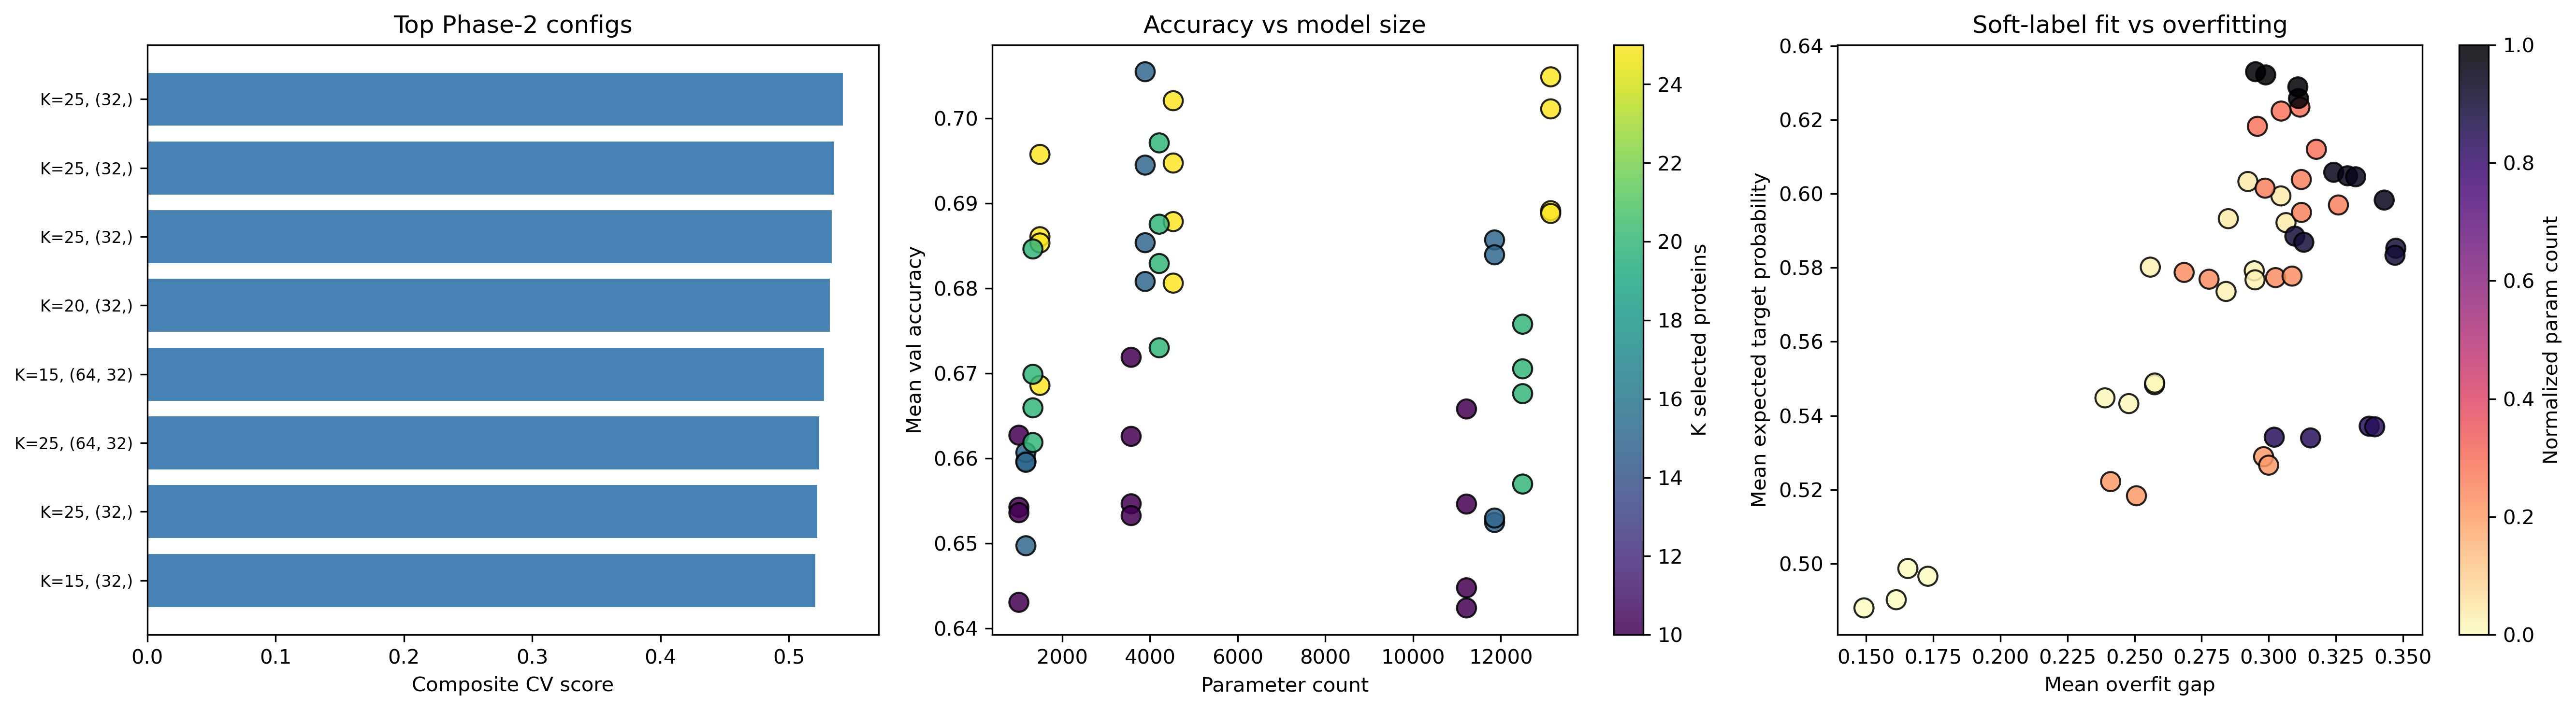


Best Phase-2 summary:
  Val accuracy             : 0.6958
  Soft target probability  : 0.6033
  Overfit gap              : 0.2922
  Top-K stability          : 0.5216


In [34]:
# ── Phase 2 CV ────────────────────────────────────────────────────────────────

PHASE2_PARAM_GRID = {
    'n_select':    [10, 15, 20, 25],
    'hidden_dims': [(32,), (64, 32), (128, 64)],
    'dropout':     [0.1, 0.2],
    'dist_lambda': [0.0, 0.1],
}

PHASE2_SELECTOR_EPOCHS = 250
PHASE2_CV_EPOCHS       = 400

phase2_cv_results, best_phase2_config = cross_validate_focused(
    X, y, sample_weights_v2, terminal_mask,
    selector_config  = best_selector_config,
    param_grid       = PHASE2_PARAM_GRID,
    groups           = groups,
    n_splits         = 5,
    selector_epochs  = PHASE2_SELECTOR_EPOCHS,
    focused_epochs   = PHASE2_CV_EPOCHS,
    selector_batch_size = 128,
    focused_batch_size  = 64,
    selector_early_stopping_patience = PHASE2_SELECTOR_EARLY_STOPPING_PATIENCE,
    focused_early_stopping_patience  = PHASE2_CV_EARLY_STOPPING_PATIENCE,
    verbose          = CV_VERBOSE,
    log_prefix       = f'stepped-avg {N_FOLDS}fold phase2',
)

phase2_rows = []
for r in phase2_cv_results:
    phase2_rows.append({**r['config'], **r['summary'], 'score': round(r['score'], 5)})
phase2_summary_df = pd.DataFrame(phase2_rows).sort_values('score', ascending=False)
best_phase2_result = phase2_cv_results[0]
N_SELECT = best_phase2_config['n_select']

display_cols2 = [
    'n_select', 'hidden_dims', 'dropout', 'dist_lambda',
    'mean_val_acc', 'mean_expected_target_probability', 'mean_soft_cross_entropy',
    'mean_overfit_gap', 'mean_jaccard', 'consensus_ratio',
    'n_parameters', 'normalized_param_count', 'score',
]
print('Top Phase-2 configs:')
display(phase2_summary_df[display_cols2].head(10).round(4))
print(f'\nBest Phase-2 config: {best_phase2_config}')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

top_n = min(8, len(phase2_summary_df))
plot_df = phase2_summary_df.head(top_n).iloc[::-1]
axes[0].barh(
    range(top_n), plot_df['score'], color='steelblue', edgecolor='white',
)
axes[0].set_yticks(range(top_n))
axes[0].set_yticklabels(
    [f"K={row.n_select}, {row.hidden_dims}" for row in plot_df.itertuples()], fontsize=8,
)
axes[0].set_xlabel('Composite CV score')
axes[0].set_title('Top Phase-2 configs')

scatter = axes[1].scatter(
    phase2_summary_df['n_parameters'], phase2_summary_df['mean_val_acc'],
    c=phase2_summary_df['n_select'], s=90, cmap='viridis', edgecolor='black', alpha=0.85,
)
axes[1].set_xlabel('Parameter count')
axes[1].set_ylabel('Mean val accuracy')
axes[1].set_title('Accuracy vs model size')
plt.colorbar(scatter, ax=axes[1], label='K selected proteins')

scatter = axes[2].scatter(
    phase2_summary_df['mean_overfit_gap'], phase2_summary_df['mean_expected_target_probability'],
    c=phase2_summary_df['normalized_param_count'], s=90, cmap='magma_r', edgecolor='black', alpha=0.85,
)
axes[2].set_xlabel('Mean overfit gap')
axes[2].set_ylabel('Mean expected target probability')
axes[2].set_title('Soft-label fit vs overfitting')
plt.colorbar(scatter, ax=axes[2], label='Normalized param count')

plt.tight_layout()
plt.show()

print(f'\nBest Phase-2 summary:')
print(f'  Val accuracy             : {best_phase2_result["summary"]["mean_val_acc"]:.4f}')
print(f'  Soft target probability  : {best_phase2_result["summary"]["mean_expected_target_probability"]:.4f}')
print(f'  Overfit gap              : {best_phase2_result["summary"]["mean_overfit_gap"]:.4f}')
print(f'  Top-K stability          : {best_phase2_result["summary"]["mean_jaccard"]:.4f}')

In [35]:
phase2_summary_df[display_cols2].to_csv(PHASE2_CV_SUMMARY_PATH, index=False)
print(f'Saved Phase-2 CV summary -> {PHASE2_CV_SUMMARY_PATH}')

Saved Phase-2 CV summary -> /Users/bingran/code/embryogenesis/expression_embedding/results/stepped_avg_5fold/phase2_cv_summary.csv


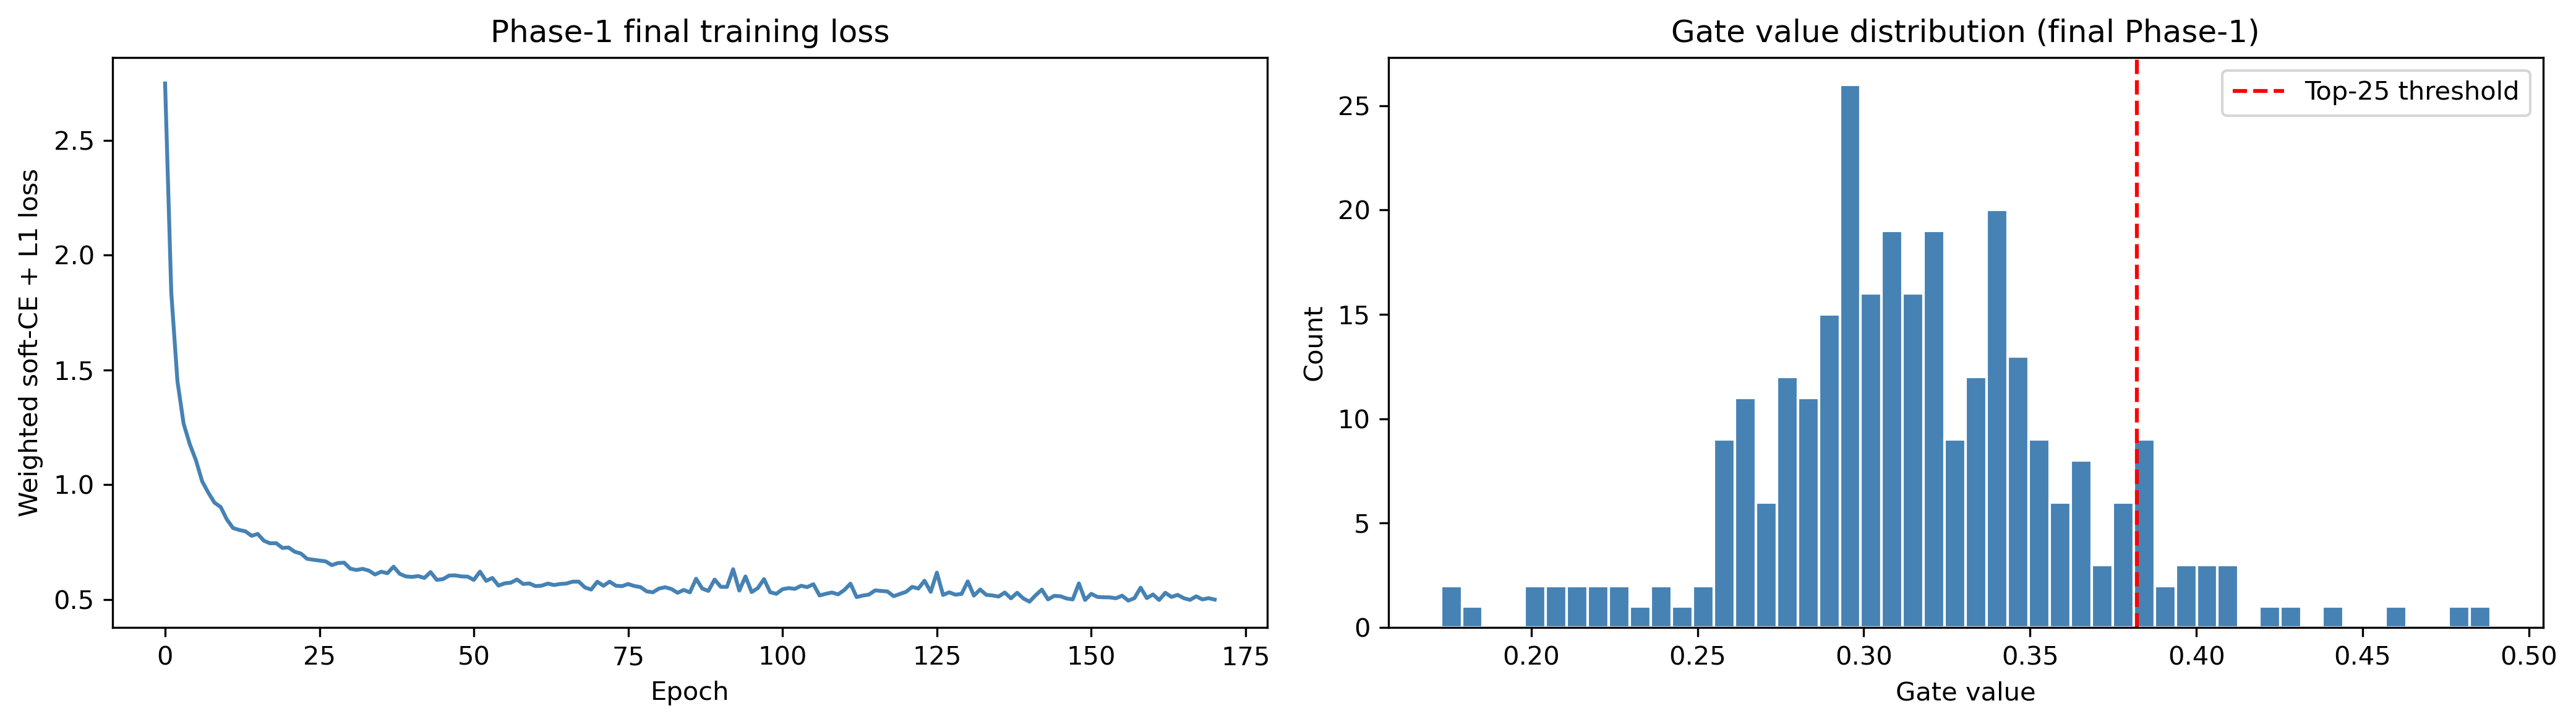

Phase-1 terminal accuracy  : 1.0000
Phase-1 selector config    : {'l1_lambda': 0.002, 'hidden_dims': (128, 64, 32), 'dropout': 0.3}
Phase-2-chosen K           : 25
Selected proteins          : ['HLH-2_SYS1049', 'PHA-4_RW10425', 'NHR-25_RW10348', 'HAM-2_SYS553', 'ELT-1_SYS121', 'SOX-2_SYS516', 'HLH-14_SYS461', 'CEH-45_SYS634', 'HLH-3_SYS222', 'ZTF-11_SYS99', 'HND-1_SYS676', 'TBX-7_SYS106', 'UNC-120_SYS167', 'M03D4.4_SYS453', 'CEH-43_SYS90', 'CEH-13_JIM356', 'CEH-51_SYS397', 'PAX-1_SYS104', 'CND-1_SYS393', 'TAB-1_SYS674', 'ARID-1_SYS679', 'EGL-44_SYS603', 'HMG-4_SYS226', 'CEBP-1_SYS451', 'ZFH-2_SYS986']


In [36]:
# ── Final Phase 1: train sparse-gate model on full boosted dataset ─────────────

model_sparse, top_idx, gate_vals, _emb_p1, losses_p1 = train_one_pass(
    X, y, sample_weights_v2,
    hidden_dims             = best_selector_config['hidden_dims'],
    l1_lambda               = best_selector_config['l1_lambda'],
    dropout                 = best_selector_config.get('dropout', 0.3),
    n_select                = N_SELECT,
    n_epochs                = 500,
    device                  = str(device),
    early_stopping_patience = FINAL_PHASE1_EARLY_STOPPING_PATIENCE,
)

X_sel   = X[:, top_idx].astype(np.float32)
X_sel_t = torch.FloatTensor(X_sel)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(losses_p1, color='steelblue')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Weighted soft-CE + L1 loss')
axes[0].set_title('Phase-1 final training loss')

axes[1].hist(gate_vals, bins=50, color='steelblue', edgecolor='white')
axes[1].axvline(
    np.sort(gate_vals)[::-1][N_SELECT - 1],
    color='red', linestyle='--', label=f'Top-{N_SELECT} threshold',
)
axes[1].set_xlabel('Gate value')
axes[1].set_ylabel('Count')
axes[1].set_title('Gate value distribution (final Phase-1)')
axes[1].legend()

plt.tight_layout()
plt.show()

final_acc_p1 = eval_accuracy(model_sparse, torch.FloatTensor(X).to(device), y_t, term_t, device)
print(f'Phase-1 terminal accuracy  : {final_acc_p1:.4f}')
print(f'Phase-1 selector config    : {best_selector_config}')
print(f'Phase-2-chosen K           : {N_SELECT}')
print(f'Selected proteins          : {feature_names[top_idx].tolist()}')

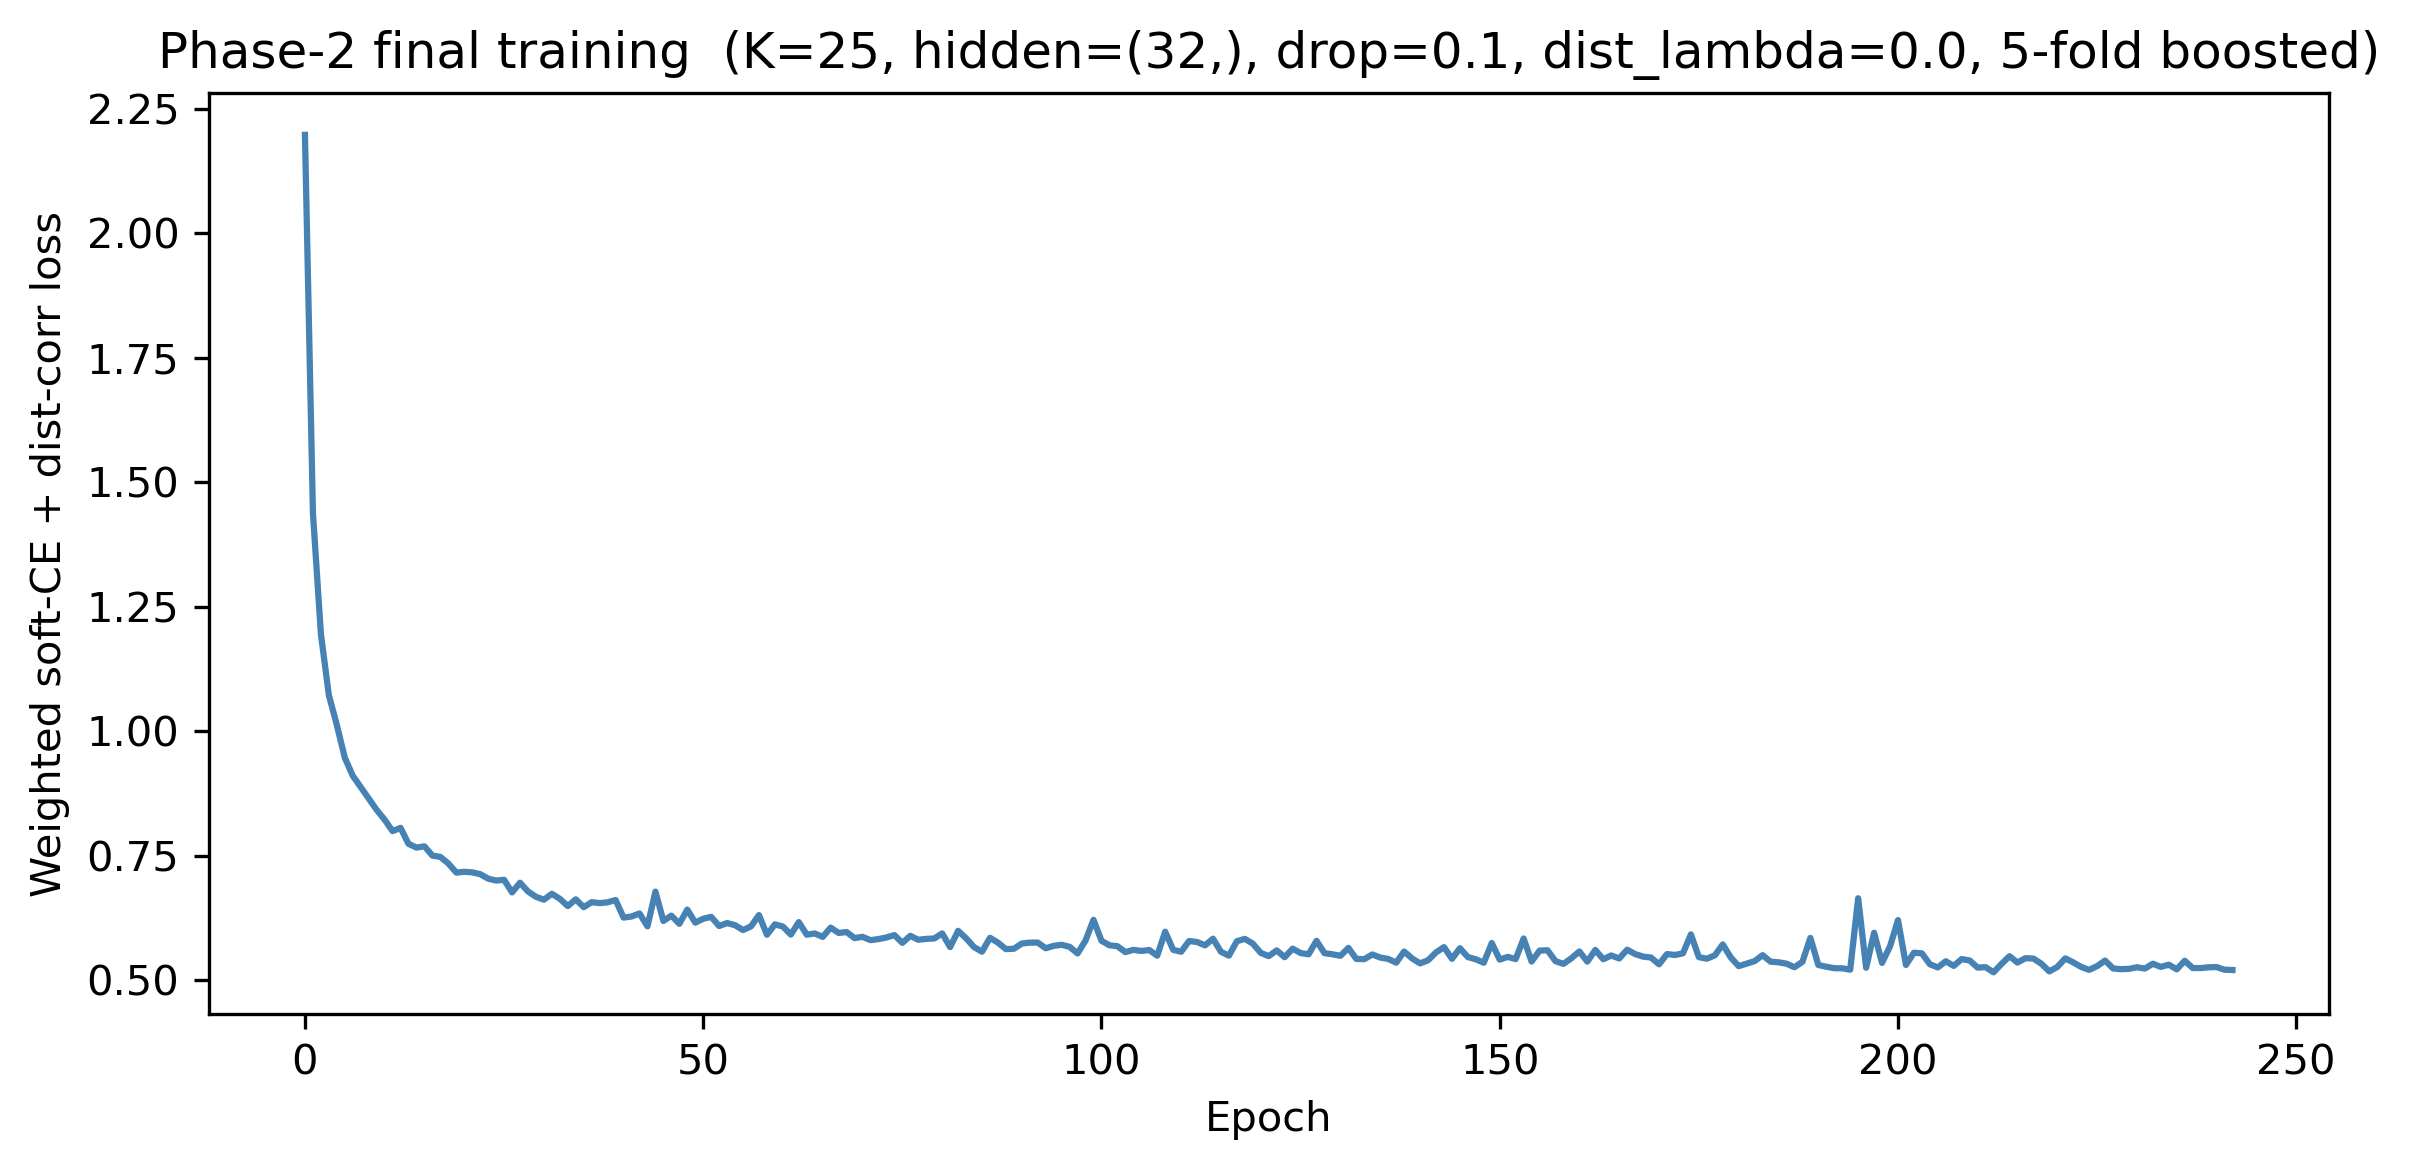

Phase-2 epochs run                   : 243
Hard-label (terminal) accuracy        : 0.9749
Soft-label dominant-class agreement   : 0.9039
Soft-label expected target prob.      : 0.7655
Soft-label cross-entropy              : 0.4259
Embedding shape                       : (6020, 32)  (boosted_samples × embed_dim)


In [37]:
# ── Final Phase 2: focused model on selected features ─────────────────────────

DIST_LAMBDA    = best_phase2_config.get('dist_lambda', 0.1)
N_EPOCHS_P2    = 600
P2_HIDDEN_DIMS = best_phase2_config['hidden_dims']
P2_DROPOUT     = best_phase2_config.get('dropout', 0.2)

model_final, embeddings, losses_p2 = train_focused(
    X_sel, y, sample_weights_v2,
    hidden_dims             = P2_HIDDEN_DIMS,
    dropout                 = P2_DROPOUT,
    n_epochs                = N_EPOCHS_P2,
    batch_size              = 64,
    seed                    = 42,
    device                  = str(device),
    dist_lambda             = DIST_LAMBDA,
    early_stopping_patience = FINAL_PHASE2_EARLY_STOPPING_PATIENCE,
)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(losses_p2, color='steelblue')
ax.set_xlabel('Epoch')
ax.set_ylabel('Weighted soft-CE + dist-corr loss')
ax.set_title(
    f'Phase-2 final training  (K={N_SELECT}, hidden={P2_HIDDEN_DIMS}, '
    f'drop={P2_DROPOUT}, dist_lambda={DIST_LAMBDA}, {N_FOLDS}-fold boosted)'
)
plt.tight_layout()
plt.show()

terminal_metrics = eval_prediction_metrics(model_final, X_sel_t, y_t, term_t, device)
all_metrics      = eval_prediction_metrics(model_final, X_sel_t, y_t, None, device, sample_weights=sample_weights_v2)

print(f'Phase-2 epochs run                   : {len(losses_p2)}')
print(f'Hard-label (terminal) accuracy        : {terminal_metrics["argmax_accuracy"]:.4f}')
print(f'Soft-label dominant-class agreement   : {all_metrics["argmax_accuracy"]:.4f}')
print(f'Soft-label expected target prob.      : {all_metrics["expected_target_probability"]:.4f}')
print(f'Soft-label cross-entropy              : {all_metrics["soft_cross_entropy"]:.4f}')
print(f'Embedding shape                       : {embeddings.shape}  (boosted_samples × embed_dim)')

In [38]:
# ── Collapse boosted embeddings to one per cell ───────────────────────────────
#
# The model was trained on N_FOLDS replicas per cell.  For downstream analysis
# and comparison with other notebooks we export one embedding per unique cell,
# computed as the mean of its N_FOLDS fold-averaged embeddings.

embed_dim = embeddings.shape[1]

# embeddings rows are ordered as: [fold_0 cells..., fold_1 cells..., fold_2 cells...]
# reshape to (N_FOLDS, N_CELLS, embed_dim) and mean over axis 0
embeddings_per_fold  = embeddings.reshape(N_FOLDS, N_CELLS, embed_dim)
cell_embeddings      = embeddings_per_fold.mean(axis=0)   # (N_CELLS, embed_dim)

# Unique cell names and corresponding single-view masks / labels
unique_cell_names  = np.array([map_names(c) for c in cell_order])
unique_term_mask   = np.array([len(descendant_list_dict[n]) == 0 for n in unique_cell_names])
unique_y           = np.array([cell_type_one_hot[n] for n in unique_cell_names])
unique_X_sel       = X_sel[:N_CELLS]   # fold_0 rows (representative single view)

print(f'Collapsed embeddings: {cell_embeddings.shape}  (unique cells × embed_dim)')
print(f'Terminal cells      : {unique_term_mask.sum()} / {len(unique_term_mask)}')

Collapsed embeddings: (1204, 32)  (unique cells × embed_dim)
Terminal cells      : 494 / 1204


Cell type                         Acc  n
---------------------------------------------
  neuron                        1.000  167
  sheath                        1.000  22
  socket                        1.000  18
  epithelium                    1.000  13
  muscle                        1.000  110
  other                         1.000  9
  marginal                      1.000  9
  hypoderm                      1.000  51
  rectal                        1.000  2
  tail                          1.000  2
  valve                         1.000  8
  intestine                     1.000  2
  mesoderm                      1.000  1
  repro                         1.000  2
  programmed_death              0.865  74
  excretory                     0.750  4


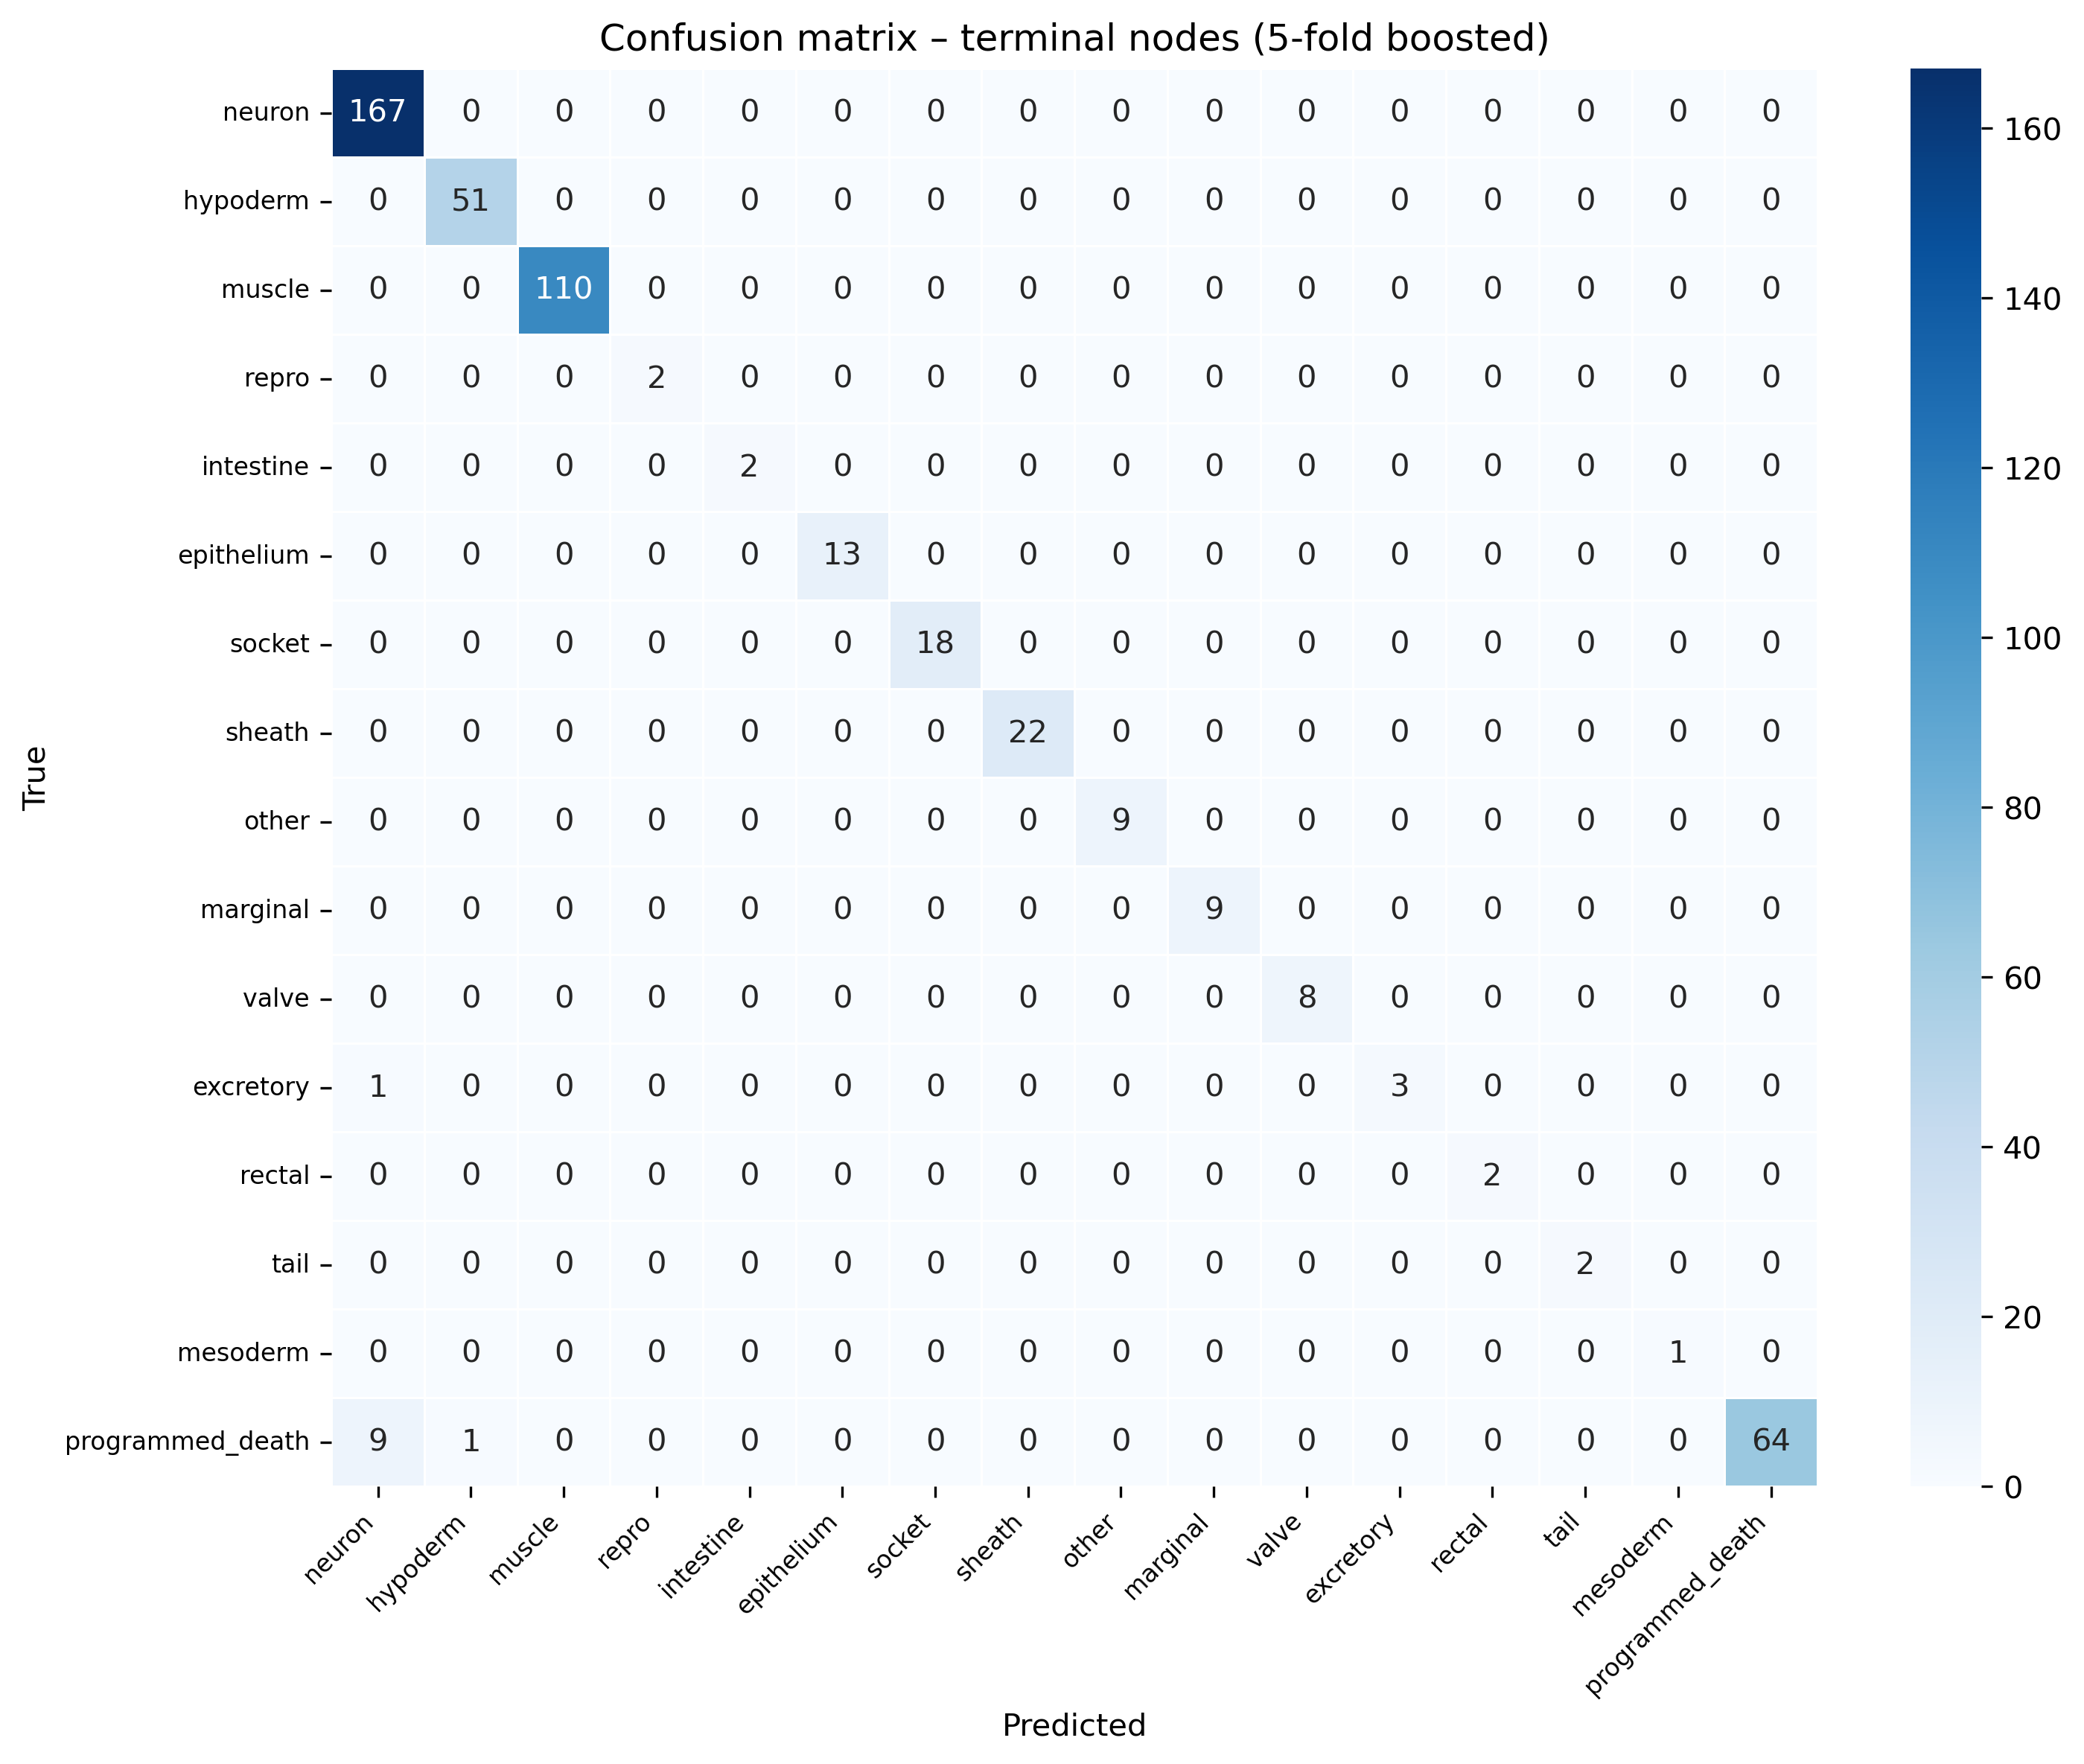

In [39]:
# ── Confusion matrix on unique terminal cells ──────────────────────────────────

model_final.eval()
with torch.no_grad():
    logits_all, _ = model_final(torch.FloatTensor(unique_X_sel).to(device))
    probs_all = F.softmax(logits_all, dim=-1).cpu().numpy()

preds_all   = probs_all.argmax(axis=1)
targets_all = unique_y.argmax(axis=1)
term_preds   = preds_all[unique_term_mask]
term_targets = targets_all[unique_term_mask]

per_type = defaultdict(list)
for p, t in zip(term_preds, term_targets):
    per_type[cell_types[t]].append(p == t)

print(f'{"Cell type":30s}  {"Acc":>5}  n')
print('-' * 45)
for ct, vals in sorted(per_type.items(), key=lambda x: -np.mean(x[1])):
    print(f'  {ct:28s}  {np.mean(vals):.3f}  {len(vals)}')

present_types = sorted(np.unique(term_targets).tolist())
conf = np.zeros((len(present_types), len(present_types)), dtype=int)
t2i  = {t: i for i, t in enumerate(present_types)}
for p, t in zip(term_preds, term_targets):
    if p in t2i:
        conf[t2i[t], t2i[p]] += 1

ct_labels = [cell_types[i] for i in present_types]
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(conf, annot=True, fmt='d', cmap='Blues',
            xticklabels=ct_labels, yticklabels=ct_labels, ax=ax, linewidths=0.3)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title(f'Confusion matrix – terminal nodes ({N_FOLDS}-fold boosted)')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

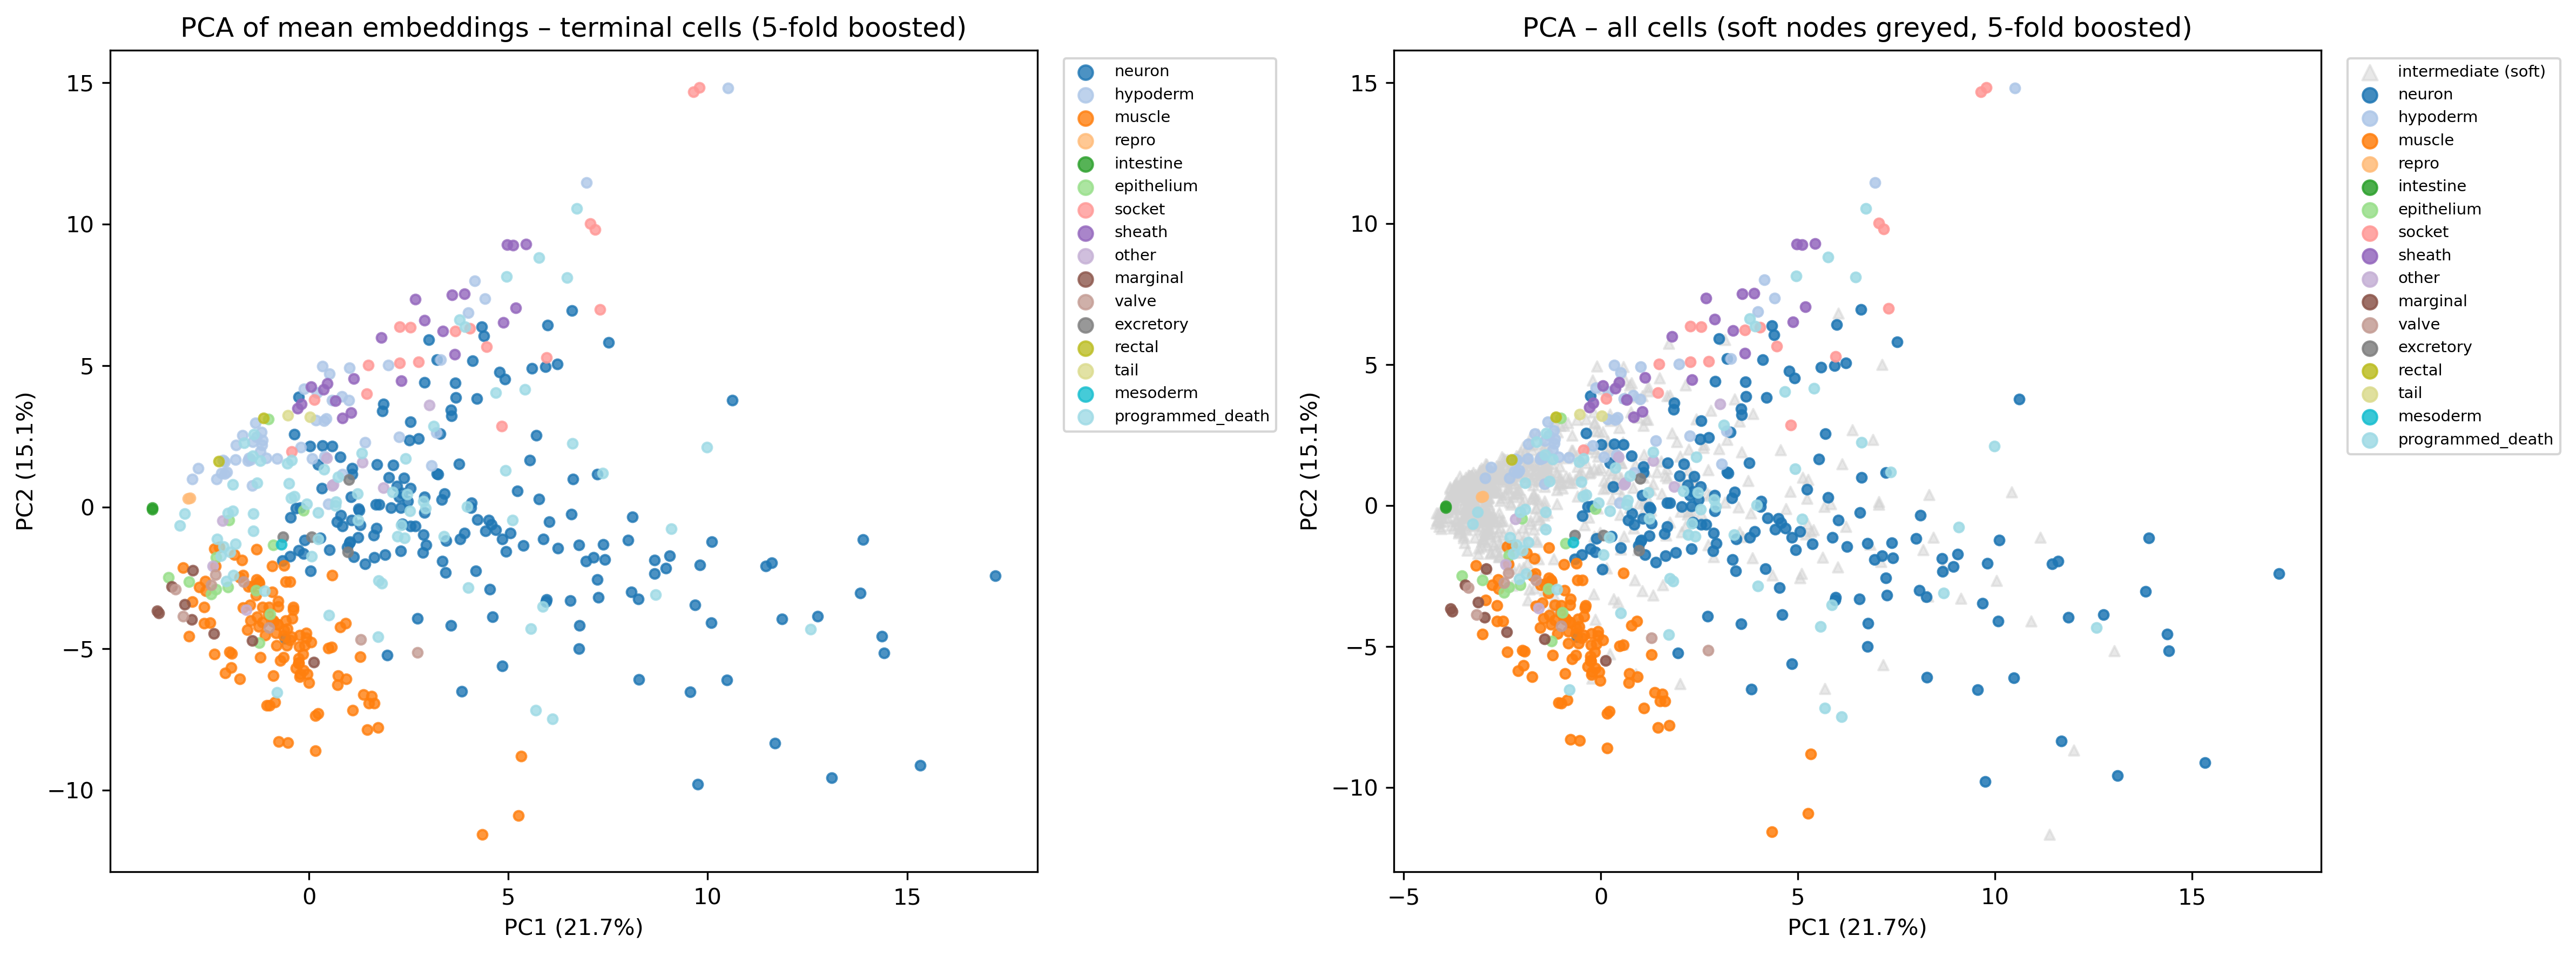

In [40]:
# ── PCA visualisation of collapsed embeddings ──────────────────────────────────

pca    = PCA(n_components=2)
emb_2d = pca.fit_transform(cell_embeddings)
ct_idx = unique_y.argmax(axis=1)
cmap   = plt.get_cmap('tab20', len(cell_types))
cell_type_colors = {ct: cmap(i) for i, ct in enumerate(cell_types)}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
for i, ct in enumerate(cell_types):
    mask_ct = (ct_idx == i) & unique_term_mask
    if mask_ct.sum() > 0:
        ax.scatter(emb_2d[mask_ct, 0], emb_2d[mask_ct, 1],
                   label=ct, s=18, alpha=0.8, color=cell_type_colors[ct], marker='o')
ax.set_title(f'PCA of mean embeddings – terminal cells ({N_FOLDS}-fold boosted)')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=7, markerscale=1.5)

ax = axes[1]
ax.scatter(emb_2d[~unique_term_mask, 0], emb_2d[~unique_term_mask, 1],
           color='lightgray', s=20, alpha=0.5, marker='^', label='intermediate (soft)')
for i, ct in enumerate(cell_types):
    mask_ct = (ct_idx == i) & unique_term_mask
    if mask_ct.sum() > 0:
        ax.scatter(emb_2d[mask_ct, 0], emb_2d[mask_ct, 1],
                   color=cell_type_colors[ct], s=18, alpha=0.85, marker='o', label=ct)
ax.set_title(f'PCA – all cells (soft nodes greyed, {N_FOLDS}-fold boosted)')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=7, markerscale=1.5)

plt.tight_layout()
plt.show()

Terminal-sibling pairs: 209  (same-type: 105, diff-type: 104)
Same-type distance: mean=6.015  median=5.292
Diff-type distance: mean=7.271  median=6.663
Mann-Whitney U (same < diff): U=3883, p=1.55e-04


/var/folders/hc/c_jc94nn46gcd5z386sfz7780000gn/T/ipykernel_26178/922551762.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x=['Same type'] * len(same_dists) + ['Diff type'] * len(diff_dists),


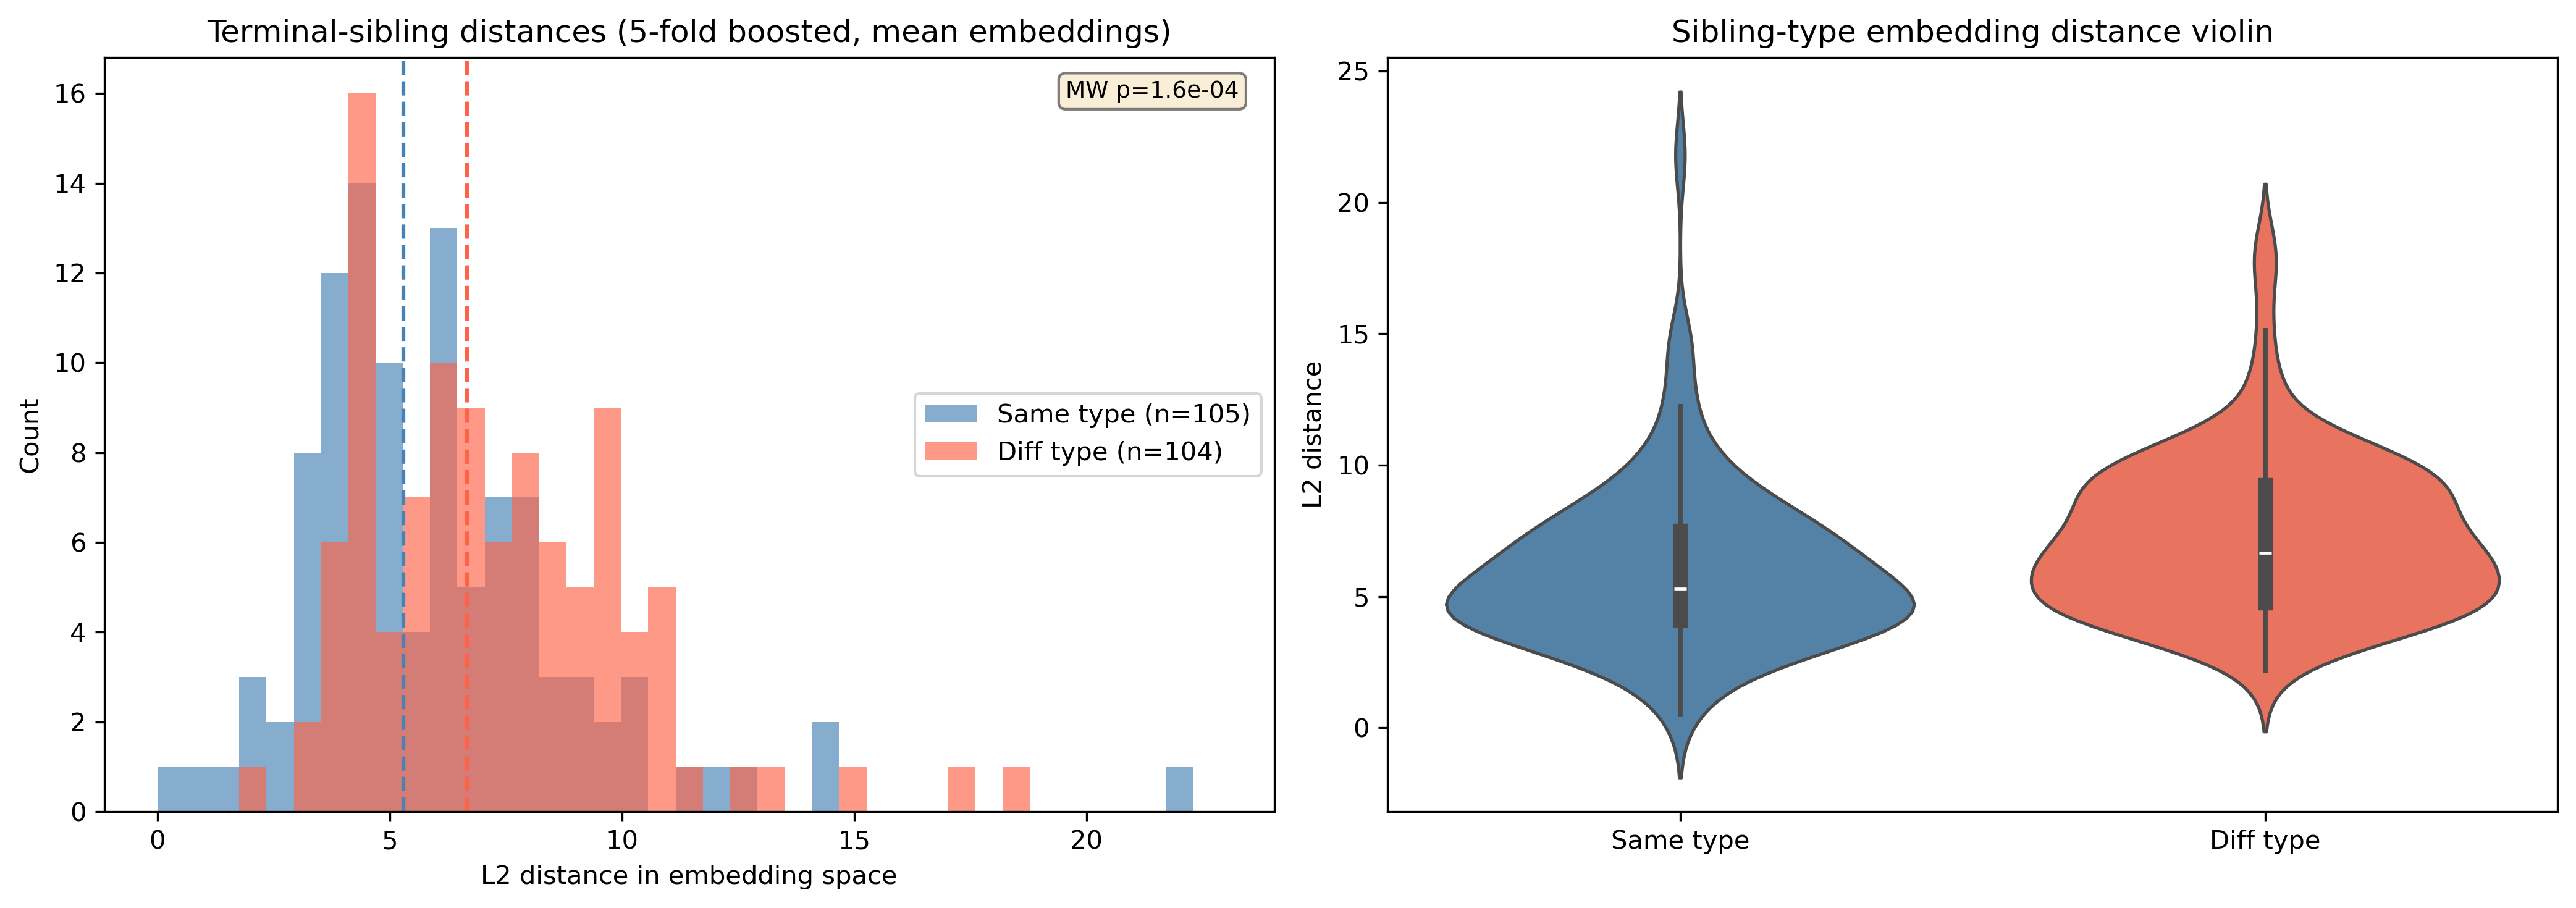

In [41]:
# ── Sibling-distance sanity check (unique cells) ───────────────────────────────

from scipy.stats import mannwhitneyu, ks_2samp
from scipy.spatial.distance import cdist

children_dict_lin = defaultdict(list)
parent_dict_lin   = {}

def build_family(node, parent_name=None):
    name = map_names(node['did'])
    if parent_name is not None:
        parent_dict_lin[name] = parent_name
        children_dict_lin[parent_name].append(name)
    for child in node.get('children', []):
        build_family(child, name)

build_family(lineage_data)

cell_name_to_idx = {name: i for i, name in enumerate(unique_cell_names)}
terminal_set     = set(unique_cell_names[unique_term_mask])

sibling_pairs = []
for parent, children in children_dict_lin.items():
    term_children = [c for c in children if c in terminal_set]
    for i in range(len(term_children)):
        for j in range(i + 1, len(term_children)):
            a, b = term_children[i], term_children[j]
            if cell_type_dict.get(a) is None or cell_type_dict.get(b) is None:
                continue
            sibling_pairs.append((a, b, cell_type_dict[a] == cell_type_dict[b]))

same_pairs = [(a, b) for a, b, s in sibling_pairs if     s]
diff_pairs = [(a, b) for a, b, s in sibling_pairs if not s]

def pair_distance(a, b, rep, name_to_idx):
    return float(np.linalg.norm(rep[name_to_idx[a]] - rep[name_to_idx[b]]))

same_dists = np.array([pair_distance(a, b, cell_embeddings, cell_name_to_idx) for a, b in same_pairs])
diff_dists = np.array([pair_distance(a, b, cell_embeddings, cell_name_to_idx) for a, b in diff_pairs])

u_stat, p_mw = mannwhitneyu(same_dists, diff_dists, alternative='less')

print(f'Terminal-sibling pairs: {len(sibling_pairs)}  (same-type: {len(same_pairs)}, diff-type: {len(diff_pairs)})')
print(f'Same-type distance: mean={same_dists.mean():.3f}  median={np.median(same_dists):.3f}')
print(f'Diff-type distance: mean={diff_dists.mean():.3f}  median={np.median(diff_dists):.3f}')
print(f'Mann-Whitney U (same < diff): U={u_stat:.0f}, p={p_mw:.2e}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
bins = np.linspace(0, max(same_dists.max(), diff_dists.max()) * 1.05, 40)
axes[0].hist(same_dists, bins=bins, alpha=0.65, color='steelblue', label=f'Same type (n={len(same_dists)})')
axes[0].hist(diff_dists, bins=bins, alpha=0.65, color='tomato',    label=f'Diff type (n={len(diff_dists)})')
axes[0].axvline(np.median(same_dists), color='steelblue', linestyle='--', linewidth=1.5)
axes[0].axvline(np.median(diff_dists), color='tomato',    linestyle='--', linewidth=1.5)
axes[0].set_xlabel('L2 distance in embedding space')
axes[0].set_ylabel('Count')
axes[0].set_title(f'Terminal-sibling distances ({N_FOLDS}-fold boosted, mean embeddings)')
axes[0].legend()
axes[0].text(0.97, 0.97, f'MW p={p_mw:.1e}', transform=axes[0].transAxes,
             ha='right', va='top', fontsize=9, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

sns.violinplot(x=['Same type'] * len(same_dists) + ['Diff type'] * len(diff_dists),
               y=np.concatenate([same_dists, diff_dists]),
               palette=['steelblue', 'tomato'], ax=axes[1])
axes[1].set_ylabel('L2 distance')
axes[1].set_title('Sibling-type embedding distance violin')

plt.tight_layout()
plt.show()

Terminal cells: 494  |  Intra-type pairs: 24404  |  Inter-type pairs: 97367


,space,same_median,diff_median,median_ratio,cohen_d,auc_like,mw_pvalue
0,Selected 25 proteins,6.1894,7.6757,1.2401,0.5001,0.6523,0.0
1,Mean embedding (32D),10.1882,12.4875,1.2257,0.5244,0.6541,0.0


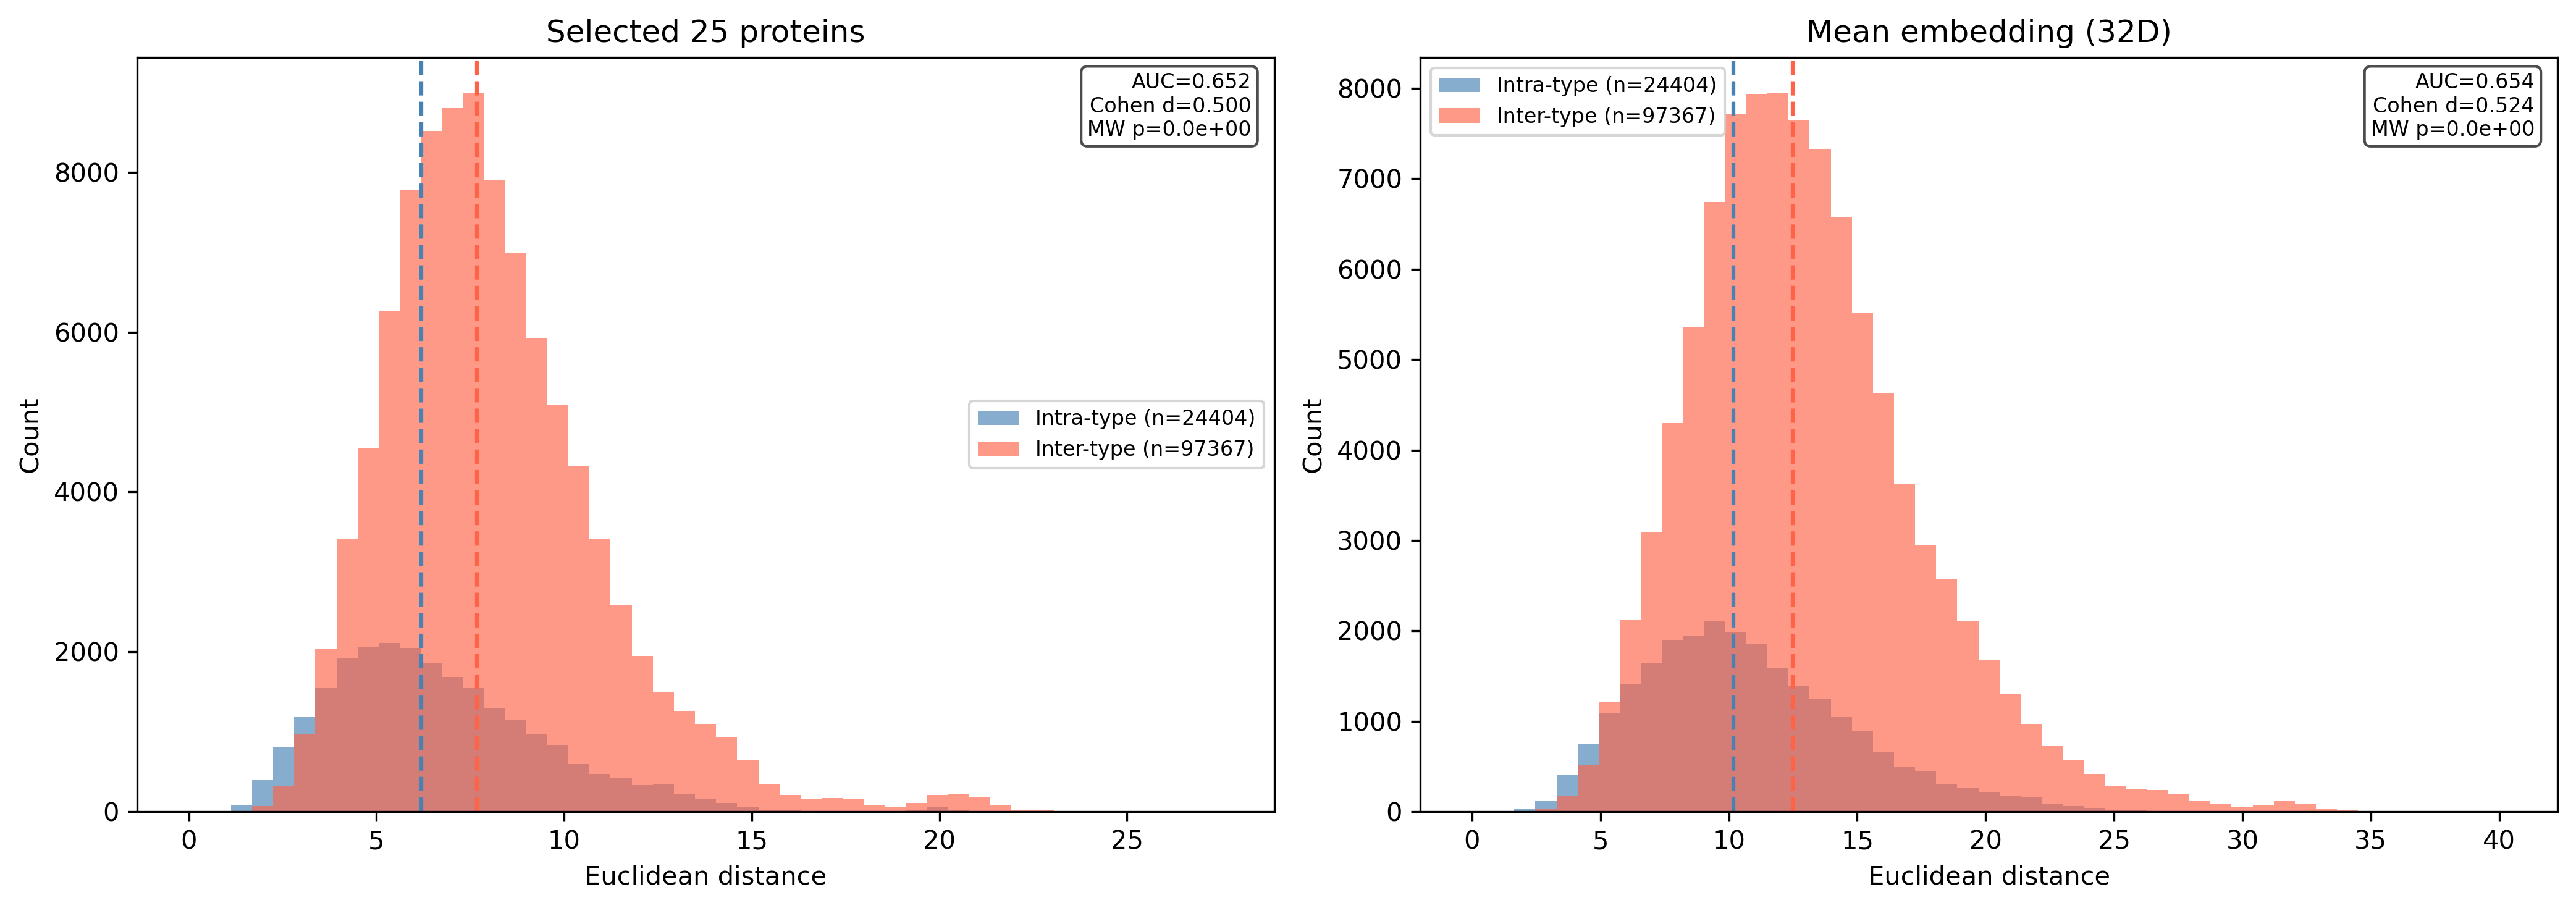

In [42]:
# ── Global terminal-pair intra vs inter-type separation ────────────────────────

from itertools import combinations

term_idx_uniq   = np.where(unique_term_mask)[0]
term_types_uniq = unique_y.argmax(axis=1)[term_idx_uniq]
term_emb_uniq   = cell_embeddings[term_idx_uniq]
term_feat_uniq  = unique_X_sel[term_idx_uniq]

emb_condensed  = pdist(term_emb_uniq,  metric='euclidean')
feat_condensed = pdist(term_feat_uniq, metric='euclidean')

n_term  = len(term_idx_uniq)
n_pairs = n_term * (n_term - 1) // 2
same_type_mask = np.fromiter(
    (term_types_uniq[i] == term_types_uniq[j] for i, j in combinations(range(n_term), 2)),
    dtype=bool, count=n_pairs,
)

emb_same  = emb_condensed[same_type_mask]
emb_diff  = emb_condensed[~same_type_mask]
feat_same = feat_condensed[same_type_mask]
feat_diff = feat_condensed[~same_type_mask]

def sep_stats(same_d, diff_d):
    u, p = mannwhitneyu(same_d, diff_d, alternative='less')
    n1, n2 = len(same_d), len(diff_d)
    s1, s2 = np.std(same_d, ddof=1), np.std(diff_d, ddof=1)
    pooled = np.sqrt(((n1-1)*s1**2 + (n2-1)*s2**2) / (n1+n2-2))
    return {
        'same_median': float(np.median(same_d)),
        'diff_median': float(np.median(diff_d)),
        'median_ratio': float(np.median(diff_d) / np.median(same_d)),
        'cohen_d': float((diff_d.mean() - same_d.mean()) / pooled),
        'auc_like': float(1.0 - u / (n1 * n2)),
        'mw_pvalue': float(p),
    }

feat_stats = sep_stats(feat_same, feat_diff)
emb_stats  = sep_stats(emb_same,  emb_diff)

summary_sep = pd.DataFrame([
    {'space': f'Selected {N_SELECT} proteins', **feat_stats},
    {'space': f'Mean embedding ({embed_dim}D)', **emb_stats},
])
print(f'Terminal cells: {n_term}  |  Intra-type pairs: {same_type_mask.sum()}  |  Inter-type pairs: {(~same_type_mask).sum()}')
display(summary_sep.round(4))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
bins_emb  = np.linspace(0, max(emb_same.max(), emb_diff.max()) * 1.05, 50)
bins_feat = np.linspace(0, max(feat_same.max(), feat_diff.max()) * 1.05, 50)

for ax, same_d, diff_d, bins, title, stats in [
    (axes[0], feat_same, feat_diff, bins_feat, f'Selected {N_SELECT} proteins', feat_stats),
    (axes[1], emb_same,  emb_diff,  bins_emb,  f'Mean embedding ({embed_dim}D)',  emb_stats),
]:
    ax.hist(same_d, bins=bins, alpha=0.65, color='steelblue', label=f'Intra-type (n={len(same_d)})')
    ax.hist(diff_d, bins=bins, alpha=0.65, color='tomato',    label=f'Inter-type (n={len(diff_d)})')
    ax.axvline(np.median(same_d), color='steelblue', linestyle='--', linewidth=1.5)
    ax.axvline(np.median(diff_d), color='tomato',    linestyle='--', linewidth=1.5)
    ax.set_title(title)
    ax.set_xlabel('Euclidean distance')
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)
    ax.text(0.98, 0.98,
            f"AUC={stats['auc_like']:.3f}\nCohen d={stats['cohen_d']:.3f}\nMW p={stats['mw_pvalue']:.1e}",
            transform=ax.transAxes, ha='right', va='top', fontsize=8,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

plt.tight_layout()
plt.show()

In [43]:
# ── Save embeddings and selected proteins ──────────────────────────────────────

top_features      = feature_names[top_idx]
trimmed_proteins  = [f.rsplit('_', 1)[0] for f in top_features]

emb_cols = [f'emb_{i}' for i in range(embed_dim)]
emb_df   = pd.DataFrame(cell_embeddings, index=unique_cell_names, columns=emb_cols)
emb_df.index.name = 'cell_name'

emb_df.to_csv(FEATURE_EMBEDDINGS_PATH)
pd.Series(trimmed_proteins).to_csv(SELECTED_PROTEINS_PATH, sep='\t', index=False, header=False)

print(f'Saved embeddings ({embed_dim}D, {len(unique_cell_names)} cells) -> {FEATURE_EMBEDDINGS_PATH}')
print(f'Saved selected proteins                                       -> {SELECTED_PROTEINS_PATH}')
print(f'Selected proteins: {trimmed_proteins}')

Saved embeddings (32D, 1204 cells) -> /Users/bingran/code/embryogenesis/expression_embedding/results/stepped_avg_5fold/embeddings_32d.csv
Saved selected proteins                                       -> /Users/bingran/code/embryogenesis/expression_embedding/results/stepped_avg_5fold/nn_selected_proteins.tsv
Selected proteins: ['HLH-2', 'PHA-4', 'NHR-25', 'HAM-2', 'ELT-1', 'SOX-2', 'HLH-14', 'CEH-45', 'HLH-3', 'ZTF-11', 'HND-1', 'TBX-7', 'UNC-120', 'M03D4.4', 'CEH-43', 'CEH-13', 'CEH-51', 'PAX-1', 'CND-1', 'TAB-1', 'ARID-1', 'EGL-44', 'HMG-4', 'CEBP-1', 'ZFH-2']


In [44]:
# ── Tissue-specific TF overlap ─────────────────────────────────────────────────

tissue_specific_tfs = pd.read_csv(TISSUE_SPECIFIC_TF_PATH, sep='\t', header=None, index_col=0).index.tolist()
tissue_overlap      = list(set(tissue_specific_tfs).intersection(set(trimmed_proteins)))

print(f'Selected proteins            : {len(trimmed_proteins)}')
print(f'Tissue-specific TFs in panel : {len(tissue_specific_tfs)}')
print(f'Overlap                      : {len(tissue_overlap)}')
print(f'Tissue-specific hits         : {sorted(tissue_overlap)}')

Selected proteins            : 25
Tissue-specific TFs in panel : 101
Overlap                      : 18
Tissue-specific hits         : ['CEH-13', 'CEH-45', 'CND-1', 'EGL-44', 'ELT-1', 'HAM-2', 'HLH-14', 'HLH-2', 'HLH-3', 'HND-1', 'M03D4.4', 'NHR-25', 'PAX-1', 'PHA-4', 'SOX-2', 'TAB-1', 'TBX-7', 'UNC-120']
